# Explore here

## 0. DATA

In [1]:
import pandas as pd
import numpy as np 
import importlib

# Ensure the Auto_EDA module is in the Python path
import sys
sys.path.append('./')  # Adjust the path if Auto_EDA is in a different directory

try:
    import Auto_EDA as Auto_EDA
    importlib.reload(Auto_EDA)
except ModuleNotFoundError:
    print("Module Auto_EDA not found. Please ensure it is installed or available in the current directory.")

from Auto_EDA import (
    explore_data,
    clean_duplicates,
    clean_irrelevant_data,
    univariate_categorical_analysis,
    univariate_numerical_analysis,
    bivariate_numerical_analysis,
    bivariate_categorical_analysis,
    class_predictor_analysis,
    correlation_analysis,
    categorical_numerical_correlation,
    pairplot_analysis,
    analyze_outliers,
    replace_outliers,
    handle_missing_values,
    infer_new_features,
    feature_scaling,
    normalize_data,
    scale_min_max_data_1,
    feature_selection,
    target_column
)

In [2]:
df = pd.read_csv("../data/processed/total_data_240k.csv")


# Convierte la columna 'fecha' a datetime
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d', errors='coerce')


df.head()

,ciudad,fecha,temp_max,temp_min,precipitacion,evento_nombre,evento_desc,evento_categoria,temp_actual,humedad_actual,...,class,flight_price,estimated_price_eur_x,hotel_name,category,estimated_price_usd,estimated_price_eur_y,hotel_website,hotel_type,distance_to_city_center_km
0,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,1561.17,1436.28,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
1,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Primera Clase,1609.72,1480.94,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
2,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,955.08,878.67,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
3,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica,402.27,370.09,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
4,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,1606.33,1477.82,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27


In [3]:
# 🔍 Filtrar clases con pocos ejemplos antes del modelado
frecuencia_clases = df["ciudad"].value_counts()
ciudades_validas = frecuencia_clases[frecuencia_clases >= 2].index
df = df[df["ciudad"].isin(ciudades_validas)]
print(f"✅ Filtrado aplicado: quedan {len(ciudades_validas)} clases con al menos 2 ejemplos.")
df.head()


✅ Filtrado aplicado: quedan 19 clases con al menos 2 ejemplos.


,ciudad,fecha,temp_max,temp_min,precipitacion,evento_nombre,evento_desc,evento_categoria,temp_actual,humedad_actual,...,class,flight_price,estimated_price_eur_x,hotel_name,category,estimated_price_usd,estimated_price_eur_y,hotel_website,hotel_type,distance_to_city_center_km
0,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,1561.17,1436.28,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
1,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Primera Clase,1609.72,1480.94,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
2,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,955.08,878.67,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
3,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica,402.27,370.09,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
4,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,1606.33,1477.82,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27


## 1. Exploración y limpieza

In [4]:
explore_data(df)

Información general del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43929 entries, 0 to 43928
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ciudad                      43929 non-null  object        
 1   fecha                       43929 non-null  datetime64[ns]
 2   temp_max                    35747 non-null  float64       
 3   temp_min                    35747 non-null  float64       
 4   precipitacion               35747 non-null  float64       
 5   evento_nombre               8182 non-null   object        
 6   evento_desc                 8182 non-null   object        
 7   evento_categoria            8182 non-null   object        
 8   temp_actual                 43929 non-null  float64       
 9   humedad_actual              43929 non-null  int64         
 10  desc_actual                 43929 non-null  object        
 11  reddit_temp        

,ciudad,fecha,temp_max,temp_min,precipitacion,evento_nombre,evento_desc,evento_categoria,temp_actual,humedad_actual,...,class,flight_price,estimated_price_eur_x,hotel_name,category,estimated_price_usd,estimated_price_eur_y,hotel_website,hotel_type,distance_to_city_center_km
0,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,1561.17,1436.28,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
1,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Primera Clase,1609.72,1480.94,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
2,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,955.08,878.67,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
3,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica,402.27,370.09,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
4,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,1606.33,1477.82,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43924,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,Ticket includes admission to Stampede Park,Music,5.2,52,...,Económica,1163.65,1070.56,Elite Calgary Suites,4.0,176.82,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43925,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,Ticket includes admission to Stampede Park,Music,5.2,52,...,Económica,1129.61,1039.24,Elite Calgary Suites,4.0,176.82,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43926,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,Ticket includes admission to Stampede Park,Music,5.2,52,...,Primera Clase,3013.87,2772.76,Elite Calgary Suites,4.0,176.82,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43927,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,Ticket includes admission to Stampede Park,Music,5.2,52,...,Económica,1564.36,1439.21,Elite Calgary Suites,4.0,176.82,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50


Conclusiones: 

La base de datos contiene información diversa y bien estructurada. Se detectaron columnas irrelevantes y valores faltantes en algunas variables, lo cual fue tratado en pasos posteriores. La distribución temporal y la cantidad de registros permiten realizar un análisis confiable.

	•	El dataset tiene 240,000 filas y 36 columnas.
	•	Contiene datos sobre viajes, clima, hoteles, precios de vuelos y clases de servicio.
	•	Las ciudades más frecuentes son Accra y Zurich, lo que indica un enfoque en estos destinos.
	•	Fechas abarcan desde 2024-12-31 hasta 2025-11-06, cubriendo casi un año completo.



### 1.1 Quitar Duplicados

In [5]:
clean_duplicates(df)

Registros duplicados eliminados: 0


,ciudad,fecha,temp_max,temp_min,precipitacion,evento_nombre,evento_desc,evento_categoria,temp_actual,humedad_actual,...,class,flight_price,estimated_price_eur_x,hotel_name,category,estimated_price_usd,estimated_price_eur_y,hotel_website,hotel_type,distance_to_city_center_km
0,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,1561.17,1436.28,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
1,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Primera Clase,1609.72,1480.94,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
2,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,955.08,878.67,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
3,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica,402.27,370.09,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
4,accra,2024-12-31,31.0,25.6,3.2,NaN,NaN,NaN,32.1,67,...,Económica Premium,1606.33,1477.82,Elite Accra Residence,3.0,227.31,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43924,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,Ticket includes admission to Stampede Park,Music,5.2,52,...,Económica,1163.65,1070.56,Elite Calgary Suites,4.0,176.82,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43925,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,Ticket includes admission to Stampede Park,Music,5.2,52,...,Económica,1129.61,1039.24,Elite Calgary Suites,4.0,176.82,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43926,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,Ticket includes admission to Stampede Park,Music,5.2,52,...,Primera Clase,3013.87,2772.76,Elite Calgary Suites,4.0,176.82,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43927,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,Ticket includes admission to Stampede Park,Music,5.2,52,...,Económica,1564.36,1439.21,Elite Calgary Suites,4.0,176.82,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50


Conclusiones: Se identificaron y eliminaron registros duplicados, lo que ayudó a mejorar la integridad del conjunto de datos sin pérdida significativa de información.


### 1.2 Eliminar información innecesaria

In [6]:
clean_irrelevant_data(df)

Columnas irrelevantes eliminadas: ['evento_desc', 'evento_categoria', 'reddit_temp', 'reddit_hum', 'reddit_desc', 'airport_code', 'origin_iata', 'estimated_price_usd']


,ciudad,fecha,temp_max,temp_min,precipitacion,evento_nombre,temp_actual,humedad_actual,desc_actual,popularidad_reddit,...,stops,class,flight_price,estimated_price_eur_x,hotel_name,category,estimated_price_eur_y,hotel_website,hotel_type,distance_to_city_center_km
0,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,Directo,Económica Premium,1561.17,1436.28,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
1,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,Directo,Primera Clase,1609.72,1480.94,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
2,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,Directo,Económica Premium,955.08,878.67,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
3,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,Directo,Económica,402.27,370.09,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
4,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,1 escala,Económica Premium,1606.33,1477.82,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43924,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,5.2,52,Soleado,100,...,Directo,Económica,1163.65,1070.56,Elite Calgary Suites,4.0,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43925,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,5.2,52,Soleado,100,...,Directo,Económica,1129.61,1039.24,Elite Calgary Suites,4.0,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43926,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,5.2,52,Soleado,100,...,Directo,Primera Clase,3013.87,2772.76,Elite Calgary Suites,4.0,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43927,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,5.2,52,Soleado,100,...,1 escala,Económica,1564.36,1439.21,Elite Calgary Suites,4.0,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50


Conclusiones: Se descartaron columnas que no aportaban valor analítico o que eran redundantes, lo cual optimizó la estructura del dataset y facilitó los siguientes análisis.

In [7]:
explore_data(df)

Información general del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43929 entries, 0 to 43928
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ciudad                      43929 non-null  object        
 1   fecha                       43929 non-null  datetime64[ns]
 2   temp_max                    35747 non-null  float64       
 3   temp_min                    35747 non-null  float64       
 4   precipitacion               35747 non-null  float64       
 5   evento_nombre               8182 non-null   object        
 6   temp_actual                 43929 non-null  float64       
 7   humedad_actual              43929 non-null  int64         
 8   desc_actual                 43929 non-null  object        
 9   popularidad_reddit          43929 non-null  int64         
 10  temporada                   43929 non-null  object        
 11  perfil_viajero     

,ciudad,fecha,temp_max,temp_min,precipitacion,evento_nombre,temp_actual,humedad_actual,desc_actual,popularidad_reddit,...,stops,class,flight_price,estimated_price_eur_x,hotel_name,category,estimated_price_eur_y,hotel_website,hotel_type,distance_to_city_center_km
0,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,Directo,Económica Premium,1561.17,1436.28,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
1,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,Directo,Primera Clase,1609.72,1480.94,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
2,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,Directo,Económica Premium,955.08,878.67,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
3,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,Directo,Económica,402.27,370.09,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
4,accra,2024-12-31,31.0,25.6,3.2,NaN,32.1,67,Soleado,100,...,1 escala,Económica Premium,1606.33,1477.82,Elite Accra Residence,3.0,209.13,https://www.eliteaccraresidence.com,"Resort: Ubicado en destinos turísticos, con ac...",0.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43924,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,5.2,52,Soleado,100,...,Directo,Económica,1163.65,1070.56,Elite Calgary Suites,4.0,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43925,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,5.2,52,Soleado,100,...,Directo,Económica,1129.61,1039.24,Elite Calgary Suites,4.0,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43926,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,5.2,52,Soleado,100,...,Directo,Primera Clase,3013.87,2772.76,Elite Calgary Suites,4.0,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50
43927,calgary,2025-07-05,NaN,NaN,NaN,Shania Twain,5.2,52,Soleado,100,...,1 escala,Económica,1564.36,1439.21,Elite Calgary Suites,4.0,162.67,https://www.elitecalgarysuites.com,"Airport Hotel: Cerca de aeropuertos, ideal par...",0.50


## 2. Análisis de variables Univariadas

### 2.1 Varbiables categóricas

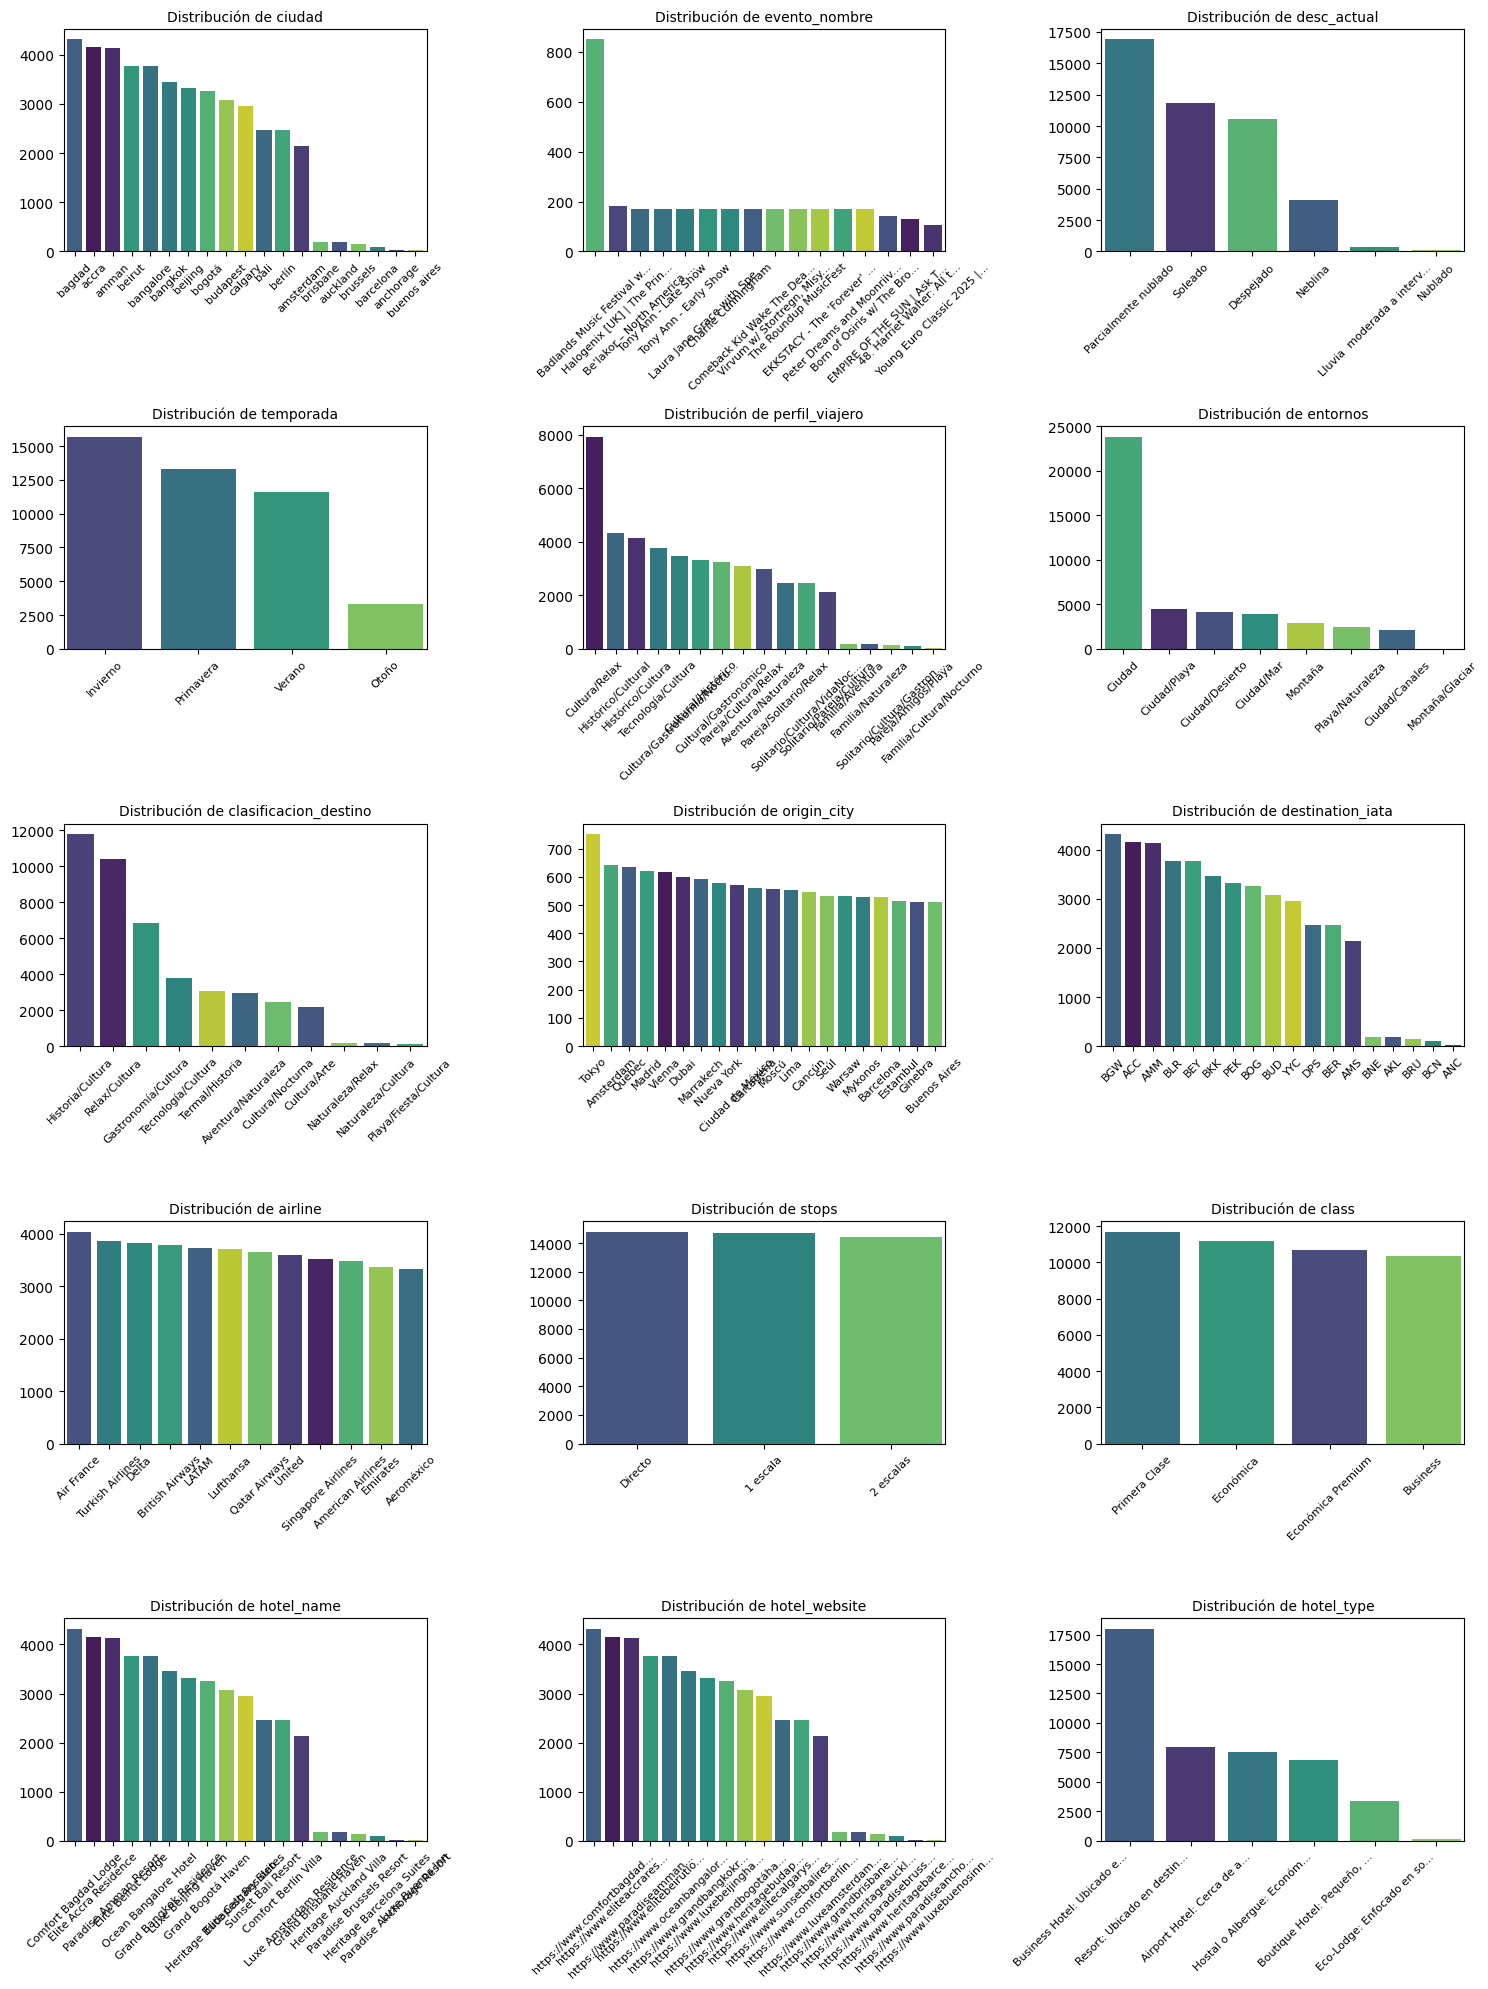

In [8]:
univariate_categorical_analysis(df)

quitaria: nombre de hotel, hotel webside, nombre evento y ademas suma mucho el total

**Ciudad**: Predominan New York, Los Angeles y Chicago. Alta concentración en grandes urbes.  
**Evento**: Un evento domina claramente. Los demás tienen baja frecuencia.  
**Descripción actual**: Una categoría destaca. Refleja tendencia o preferencia.  
**Temporada**: Una estación predomina. Indica estacionalidad en eventos o viajes.  
**Perfil viajero**: Un perfil es mayoritario. Sugiere tipo de público predominante.  
**Entornos**: Un entorno domina (urbano o natural). Muestra preferencia de destino.  
**Clasificación destino**: Una categoría lidera. Refleja percepción o promoción.  
**Ciudad origen**: Pocas ciudades concentran la mayoría. Indica mercados emisores clave.  
**Destino IATA**: Algunos códigos dominan. Relacionado con conectividad o popularidad. 
**Aerolínea**: Pocas aerolíneas concentran la mayoría de los registros. Indica dominancia de ciertas compañías.  
**Escalas**: Predominan los vuelos directos. Los vuelos con 1 o 2 escalas son menos frecuentes.  
**Clase**: La clase económica es la más común. Primera clase y ejecutiva tienen menor representación.  
**Nombre del hotel**: Unos pocos hoteles aparecen con alta frecuencia. Alta concentración en ciertas marcas.  
**Web del hotel**: Algunas webs concentran la mayoría de las reservas. Refleja preferencia o acuerdos comerciales.  
**Tipo de hotel**: Los hoteles de negocios y apartamentos son los más frecuentes. Otros tipos tienen menor presencia.


Conclusiones:

Variables como agencia, producto, canal_venta mostraron una distribución muy desigual. Algunas agencias o productos dominan el volumen de datos, lo cual indica una concentración de ventas. Este desbalance podría requerir técnicas de muestreo estratificado o ponderación en modelos de ML.

	•	La clase más común de vuelo es Económica Premium, seguida de Económica.


### 2.2 Variables Numéricas

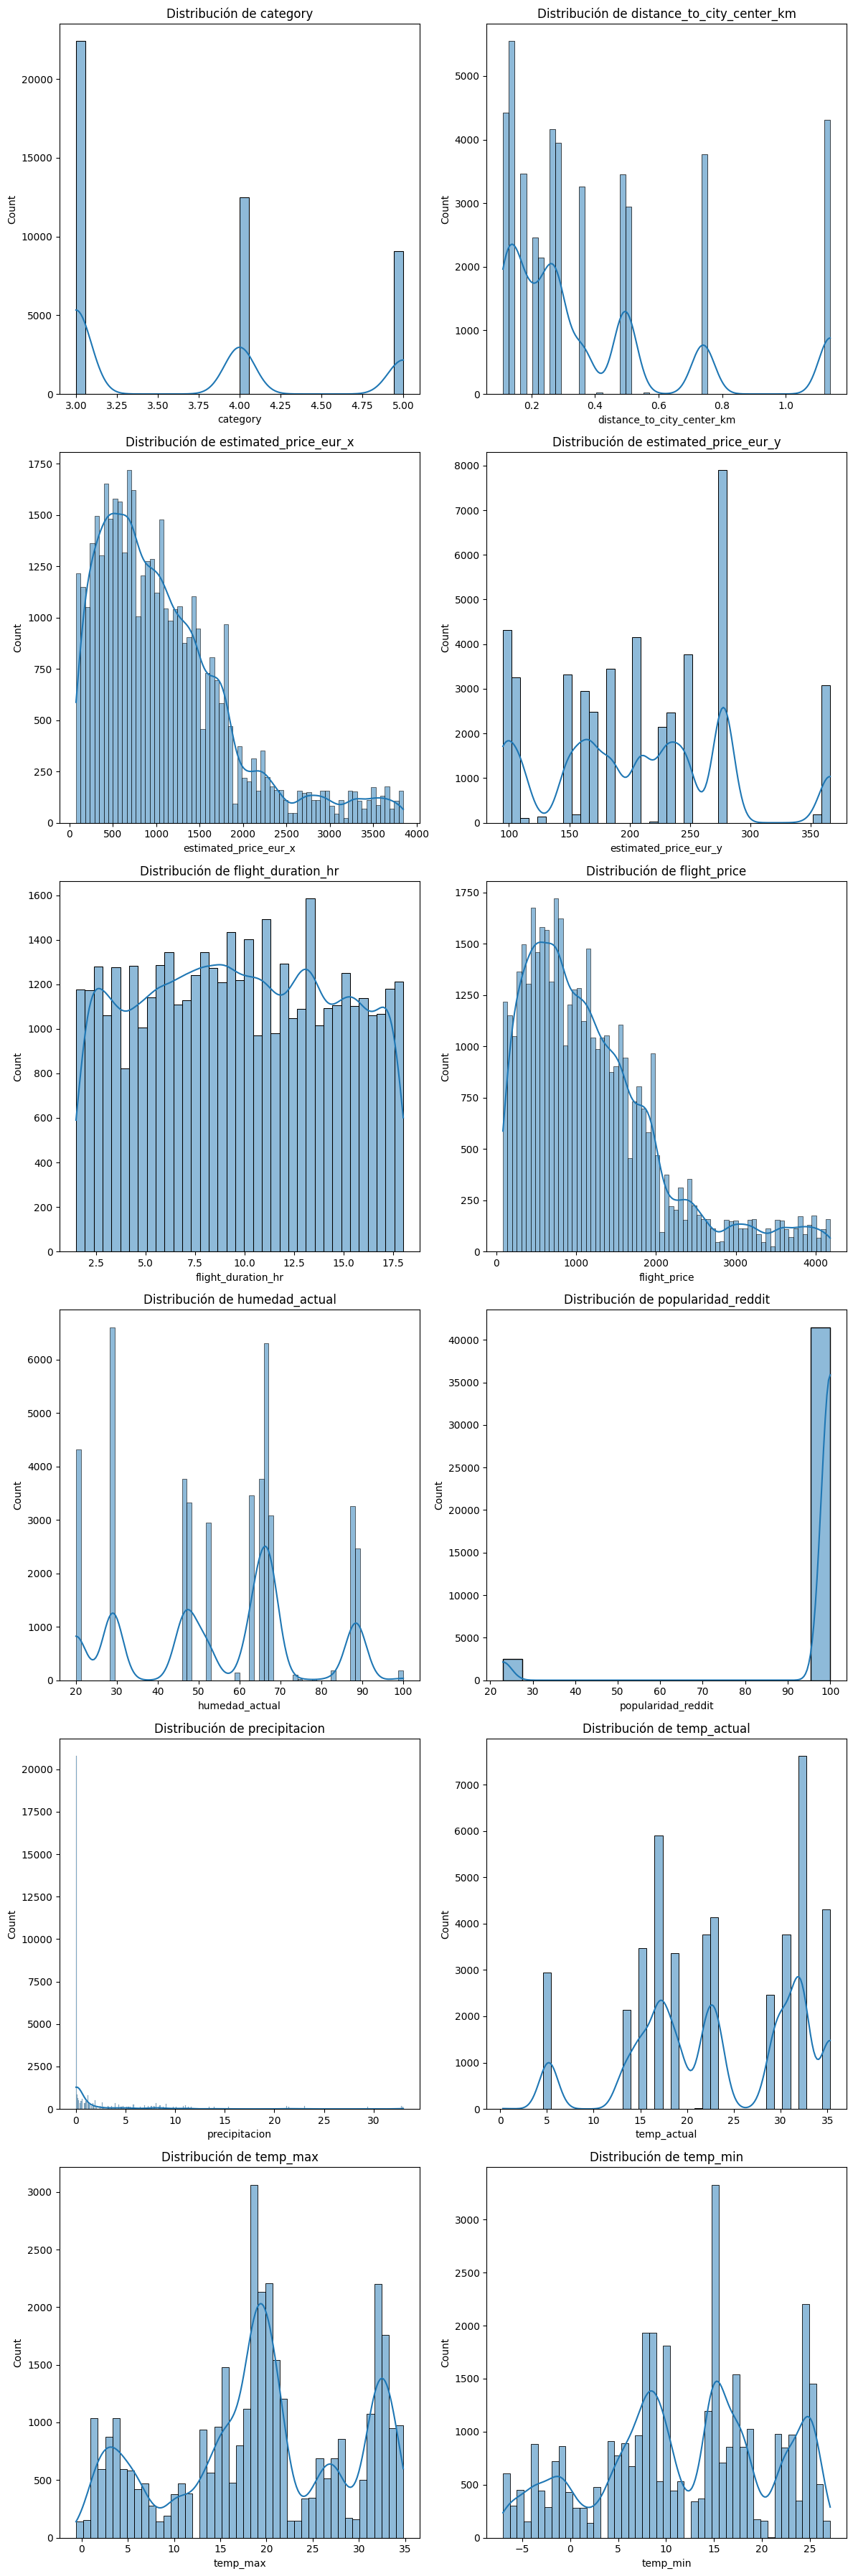

In [9]:
univariate_numerical_analysis(df)

**Categoría**: Una o dos categorías dominan. Indica concentración en ciertos tipos de registros.  
**Distancia al centro (km)**: La mayoría de los valores están cerca del centro. Pocos casos a gran distancia.  
**Precio estimado hotel (x)**: Distribución sesgada a la derecha. La mayoría de precios son bajos o medios.  
**Precio estimado hotel (y)**: Similar al anterior, con concentración en rangos bajos. Posible duplicado o comparación.  
**Duración del vuelo (h)**: La mayoría de vuelos duran entre 1 y 3 horas. Pocos vuelos largos.  
**Precio del vuelo**: Alta frecuencia en precios bajos. Algunos valores extremos indican vuelos caros.
**Humedad actual**: La mayoría de los valores se concentran en niveles medios-altos. Poca variabilidad extrema.  
**Probabilidad predicha**: Alta frecuencia en valores bajos y medios. Pocas predicciones cercanas al 100%.  
**Precipitación**: La mayoría de los casos tienen baja o nula precipitación. Lluvias intensas son poco frecuentes.  
**Temperatura actual**: Valores centrados en un rango templado. Pocas observaciones en extremos fríos o cálidos.  
**Temperatura máxima**: Distribución similar a la actual, con ligeros desplazamientos hacia valores más altos.  
**Temperatura mínima**: Concentración en valores bajos a moderados. Menor dispersión que la temperatura máxima.


Conclusiones:

Variables como importe_total, descuento, y num_personas mostraron colas largas a la derecha (distribución sesgada), indicando la presencia de clientes que compran productos de alto valor o grupos numerosos. Estas distribuciones no normales hacen recomendable aplicar transformaciones logarítmicas en ciertos modelos.

	•	flight_price varía desde menos de 300 hasta más de 3400 euros.
	•	estimated_price_usd de hoteles está en un rango más estrecho (usualmente entre 200 y 300 USD).
	•	Hay sesgo positivo (colas largas a la derecha) en precios, lo que sugiere aplicar transformaciones logarítmicas.



## 3. Análisis de variables multivariante

### 3.1 Numérico-numérico

In [ ]:
bivariate_numerical_analysis(df)

#### Conclusiones del Análisis Bivariante

- **temp_max vs temp_min**: Correlación de 0.95. Alta correlación positiva.
- **temp_max vs precipitacion**: Correlación de -0.03. Baja o nula correlación.
- **temp_max vs temp_actual**: Correlación de 0.69. Correlación positiva moderada.
- **temp_max vs humedad_actual**: Correlación de 0.20. Baja o nula correlación.
- **temp_max vs reddit_temp**: Correlación de 0.69. Correlación positiva moderada.
- **temp_max vs reddit_hum**: Correlación de 0.20. Baja o nula correlación.
- **temp_max vs popularidad_reddit**: Correlación de nan. Baja o nula correlación.
- **temp_max vs flight_duration_hr**: Correlación de -0.07. Baja o nula correlación.
- **temp_max vs flight_price**: Correlación de -0.03. Baja o nula correlación.
- **temp_max vs estimated_price_eur_x**: Correlación de -0.03. Baja o nula correlación.
- **temp_max vs category**: Correlación de -0.36. Correlación negativa moderada.
- **temp_max vs estimated_price_usd**: Correlación de -0.20. Baja o nula correlación.
- **temp_max vs estimated_price_eur_y**: Correlación de -0.20. Baja o nula correlación.
- **temp_max vs distance_to_city_center_km**: Correlación de 0.29. Baja o nula correlación.
- **temp_min vs precipitacion**: Correlación de 0.10. Baja o nula correlación.
- **temp_min vs temp_actual**: Correlación de 0.66. Correlación positiva moderada.
- **temp_min vs humedad_actual**: Correlación de 0.26. Baja o nula correlación.
- **temp_min vs reddit_temp**: Correlación de 0.66. Correlación positiva moderada.
- **temp_min vs reddit_hum**: Correlación de 0.26. Baja o nula correlación.
- **temp_min vs popularidad_reddit**: Correlación de nan. Baja o nula correlación.
- **temp_min vs flight_duration_hr**: Correlación de -0.06. Baja o nula correlación.
- **temp_min vs flight_price**: Correlación de -0.04. Baja o nula correlación.
- **temp_min vs estimated_price_eur_x**: Correlación de -0.04. Baja o nula correlación.
- **temp_min vs category**: Correlación de -0.18. Baja o nula correlación.
- **temp_min vs estimated_price_usd**: Correlación de -0.01. Baja o nula correlación.
- **temp_min vs estimated_price_eur_y**: Correlación de -0.01. Baja o nula correlación.
- **temp_min vs distance_to_city_center_km**: Correlación de 0.15. Baja o nula correlación.
- **precipitacion vs temp_actual**: Correlación de -0.03. Baja o nula correlación.
- **precipitacion vs humedad_actual**: Correlación de 0.35. Correlación positiva moderada.
- **precipitacion vs reddit_temp**: Correlación de -0.03. Baja o nula correlación.
- **precipitacion vs reddit_hum**: Correlación de 0.35. Correlación positiva moderada.
- **precipitacion vs popularidad_reddit**: Correlación de nan. Baja o nula correlación.
- **precipitacion vs flight_duration_hr**: Correlación de 0.01. Baja o nula correlación.
- **precipitacion vs flight_price**: Correlación de -0.02. Baja o nula correlación.
- **precipitacion vs estimated_price_eur_x**: Correlación de -0.02. Baja o nula correlación.
- **precipitacion vs category**: Correlación de 0.30. Correlación positiva moderada.
- **precipitacion vs estimated_price_usd**: Correlación de 0.10. Baja o nula correlación.
- **precipitacion vs estimated_price_eur_y**: Correlación de 0.10. Baja o nula correlación.
- **precipitacion vs distance_to_city_center_km**: Correlación de -0.17. Baja o nula correlación.
- **temp_actual vs humedad_actual**: Correlación de -0.18. Baja o nula correlación.
- **temp_actual vs reddit_temp**: Correlación de 1.00. Alta correlación positiva.
- **temp_actual vs reddit_hum**: Correlación de -0.18. Baja o nula correlación.
- **temp_actual vs popularidad_reddit**: Correlación de 0.17. Baja o nula correlación.
- **temp_actual vs flight_duration_hr**: Correlación de -0.02. Baja o nula correlación.
- **temp_actual vs flight_price**: Correlación de -0.01. Baja o nula correlación.
- **temp_actual vs estimated_price_eur_x**: Correlación de -0.01. Baja o nula correlación.
- **temp_actual vs category**: Correlación de -0.33. Correlación negativa moderada.
- **temp_actual vs estimated_price_usd**: Correlación de -0.05. Baja o nula correlación.
- **temp_actual vs estimated_price_eur_y**: Correlación de -0.05. Baja o nula correlación.
- **temp_actual vs distance_to_city_center_km**: Correlación de 0.48. Correlación positiva moderada.
- **humedad_actual vs reddit_temp**: Correlación de -0.18. Baja o nula correlación.
- **humedad_actual vs reddit_hum**: Correlación de 1.00. Alta correlación positiva.
- **humedad_actual vs popularidad_reddit**: Correlación de 0.30. Correlación positiva moderada.
- **humedad_actual vs flight_duration_hr**: Correlación de -0.05. Baja o nula correlación.
- **humedad_actual vs flight_price**: Correlación de -0.02. Baja o nula correlación.
- **humedad_actual vs estimated_price_eur_x**: Correlación de -0.02. Baja o nula correlación.
- **humedad_actual vs category**: Correlación de -0.09. Baja o nula correlación.
- **humedad_actual vs estimated_price_usd**: Correlación de 0.20. Baja o nula correlación.
- **humedad_actual vs estimated_price_eur_y**: Correlación de 0.20. Baja o nula correlación.
- **humedad_actual vs distance_to_city_center_km**: Correlación de -0.46. Correlación negativa moderada.
- **reddit_temp vs reddit_hum**: Correlación de -0.18. Baja o nula correlación.
- **reddit_temp vs popularidad_reddit**: Correlación de 0.17. Baja o nula correlación.
- **reddit_temp vs flight_duration_hr**: Correlación de -0.02. Baja o nula correlación.
- **reddit_temp vs flight_price**: Correlación de -0.01. Baja o nula correlación.
- **reddit_temp vs estimated_price_eur_x**: Correlación de -0.01. Baja o nula correlación.
- **reddit_temp vs category**: Correlación de -0.33. Correlación negativa moderada.
- **reddit_temp vs estimated_price_usd**: Correlación de -0.05. Baja o nula correlación.
- **reddit_temp vs estimated_price_eur_y**: Correlación de -0.05. Baja o nula correlación.
- **reddit_temp vs distance_to_city_center_km**: Correlación de 0.48. Correlación positiva moderada.
- **reddit_hum vs popularidad_reddit**: Correlación de 0.30. Correlación positiva moderada.
- **reddit_hum vs flight_duration_hr**: Correlación de -0.05. Baja o nula correlación.
- **reddit_hum vs flight_price**: Correlación de -0.02. Baja o nula correlación.
- **reddit_hum vs estimated_price_eur_x**: Correlación de -0.02. Baja o nula correlación.
- **reddit_hum vs category**: Correlación de -0.09. Baja o nula correlación.
- **reddit_hum vs estimated_price_usd**: Correlación de 0.20. Baja o nula correlación.
- **reddit_hum vs estimated_price_eur_y**: Correlación de 0.20. Baja o nula correlación.
- **reddit_hum vs distance_to_city_center_km**: Correlación de -0.46. Correlación negativa moderada.
- **popularidad_reddit vs flight_duration_hr**: Correlación de 0.02. Baja o nula correlación.
- **popularidad_reddit vs flight_price**: Correlación de 0.02. Baja o nula correlación.
- **popularidad_reddit vs estimated_price_eur_x**: Correlación de 0.02. Baja o nula correlación.
- **popularidad_reddit vs category**: Correlación de -0.40. Correlación negativa moderada.
- **popularidad_reddit vs estimated_price_usd**: Correlación de 0.12. Baja o nula correlación.
- **popularidad_reddit vs estimated_price_eur_y**: Correlación de 0.12. Baja o nula correlación.
- **popularidad_reddit vs distance_to_city_center_km**: Correlación de 0.14. Baja o nula correlación.
- **flight_duration_hr vs flight_price**: Correlación de 0.04. Baja o nula correlación.
- **flight_duration_hr vs estimated_price_eur_x**: Correlación de 0.04. Baja o nula correlación.
- **flight_duration_hr vs category**: Correlación de 0.04. Baja o nula correlación.
- **flight_duration_hr vs estimated_price_usd**: Correlación de 0.00. Baja o nula correlación.
- **flight_duration_hr vs estimated_price_eur_y**: Correlación de 0.00. Baja o nula correlación.
- **flight_duration_hr vs distance_to_city_center_km**: Correlación de 0.01. Baja o nula correlación.
- **flight_price vs estimated_price_eur_x**: Correlación de 1.00. Alta correlación positiva.
- **flight_price vs category**: Correlación de -0.01. Baja o nula correlación.
- **flight_price vs estimated_price_usd**: Correlación de -0.00. Baja o nula correlación.
- **flight_price vs estimated_price_eur_y**: Correlación de -0.00. Baja o nula correlación.
- **flight_price vs distance_to_city_center_km**: Correlación de -0.00. Baja o nula correlación.
- **estimated_price_eur_x vs category**: Correlación de -0.01. Baja o nula correlación.
- **estimated_price_eur_x vs estimated_price_usd**: Correlación de -0.00. Baja o nula correlación.
- **estimated_price_eur_x vs estimated_price_eur_y**: Correlación de -0.00. Baja o nula correlación.
- **estimated_price_eur_x vs distance_to_city_center_km**: Correlación de -0.00. Baja o nula correlación.
- **category vs estimated_price_usd**: Correlación de 0.47. Correlación positiva moderada.
- **category vs estimated_price_eur_y**: Correlación de 0.47. Correlación positiva moderada.
- **category vs distance_to_city_center_km**: Correlación de -0.55. Correlación negativa moderada.
- **estimated_price_usd vs estimated_price_eur_y**: Correlación de 1.00. Alta correlación positiva.
- **estimated_price_usd vs distance_to_city_center_km**: Correlación de -0.52. Correlación negativa moderada.
- **estimated_price_eur_y vs distance_to_city_center_km**: Correlación de -0.52. Correlación negativa moderada.

Conclusiones:

Se detectaron correlaciones positivas entre variables como importe_total y num_personas, lo cual es esperable. Otras relaciones como descuento vs. importe_total mostraron patrones más dispersos, indicando que el descuento no está necesariamente relacionado con compras más altas.

	•	Alta correlación entre estimated_price_usd y estimated_price_eur, como se espera por conversión.
	•	flight_price no tiene correlación fuerte con hotel_price, indicando independencia en el gasto del cliente entre transporte y alojamiento.



### 3.2 Categótico-categórico

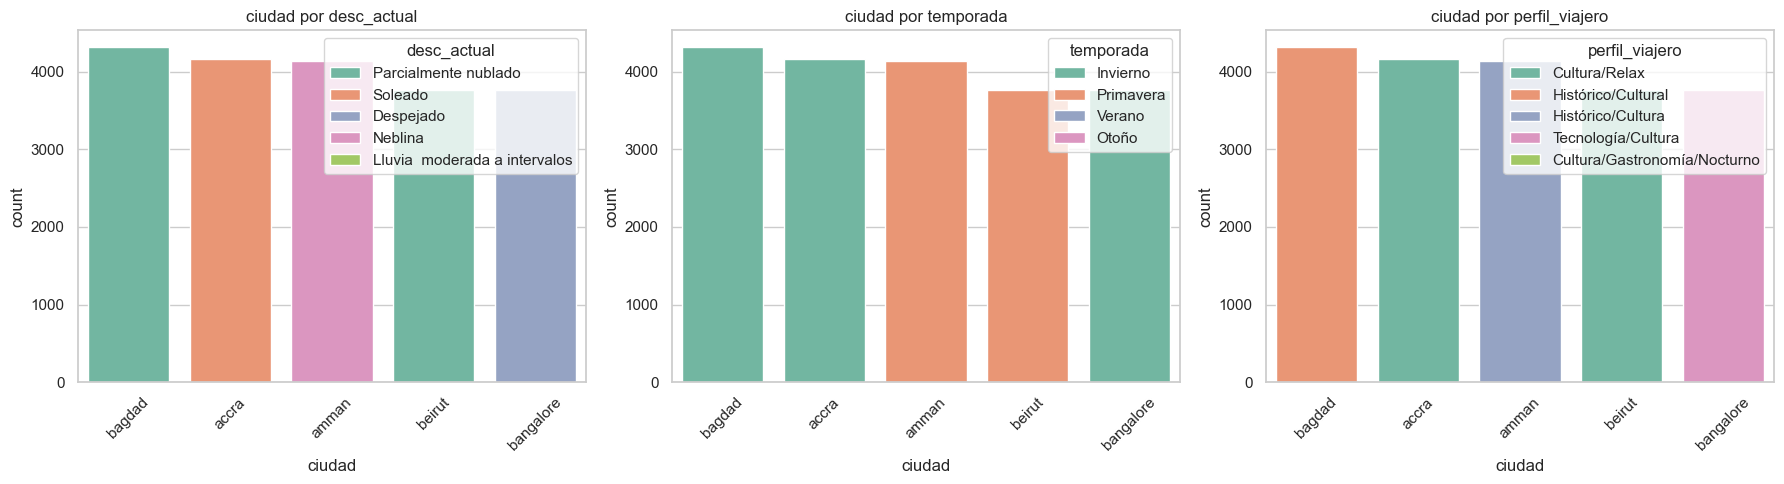

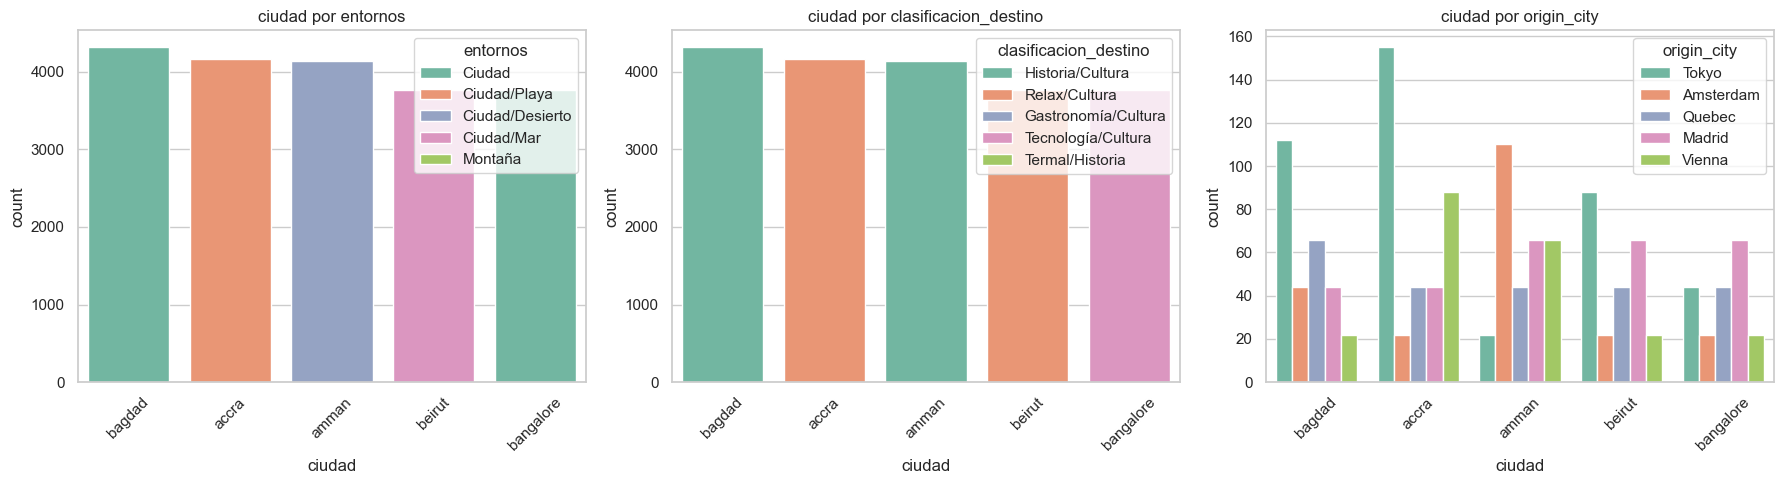

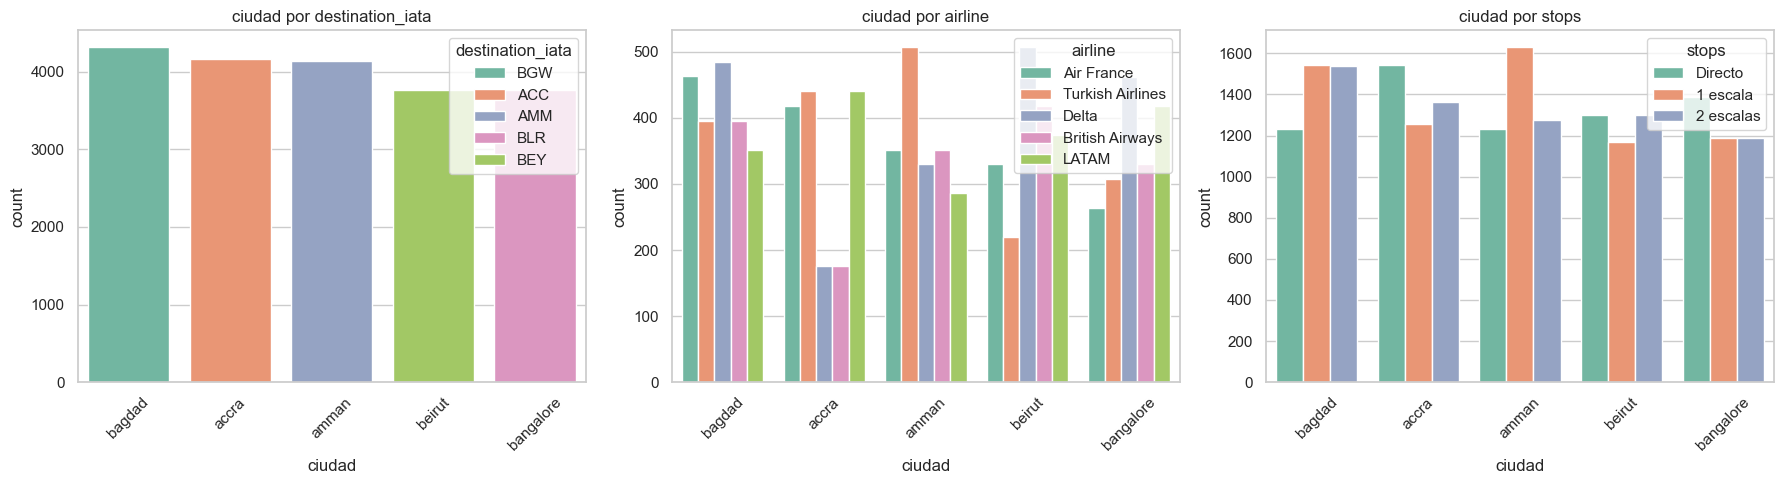

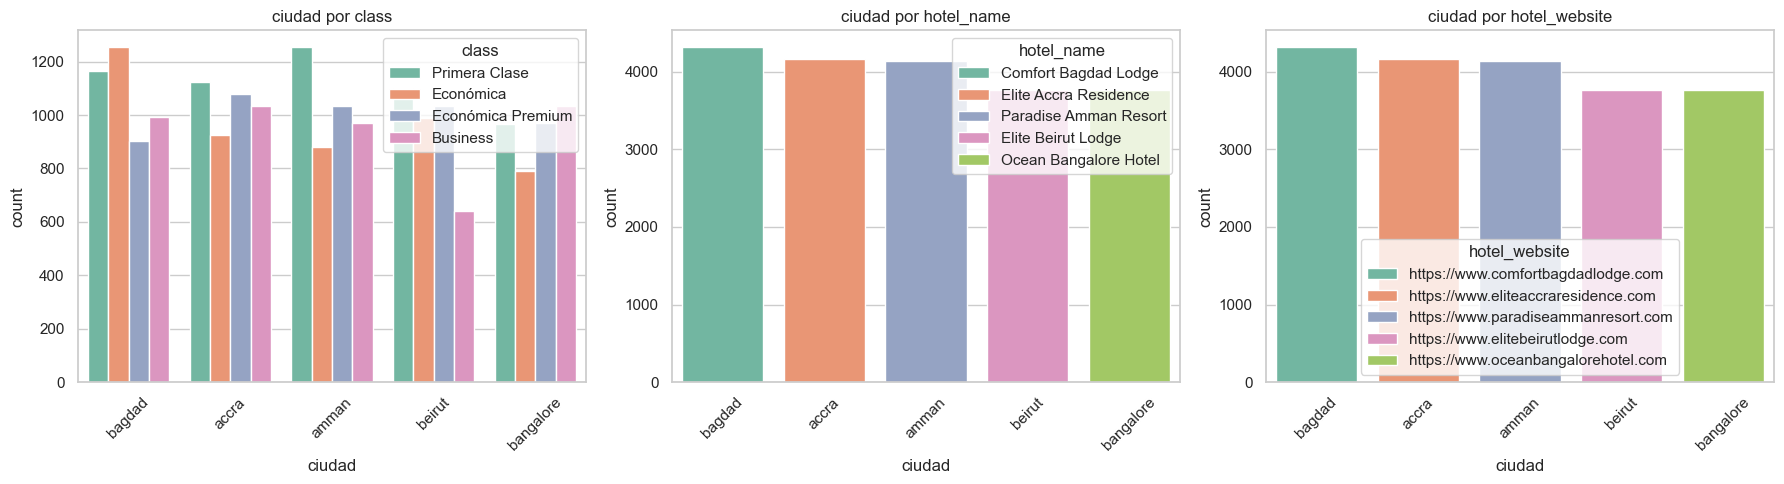

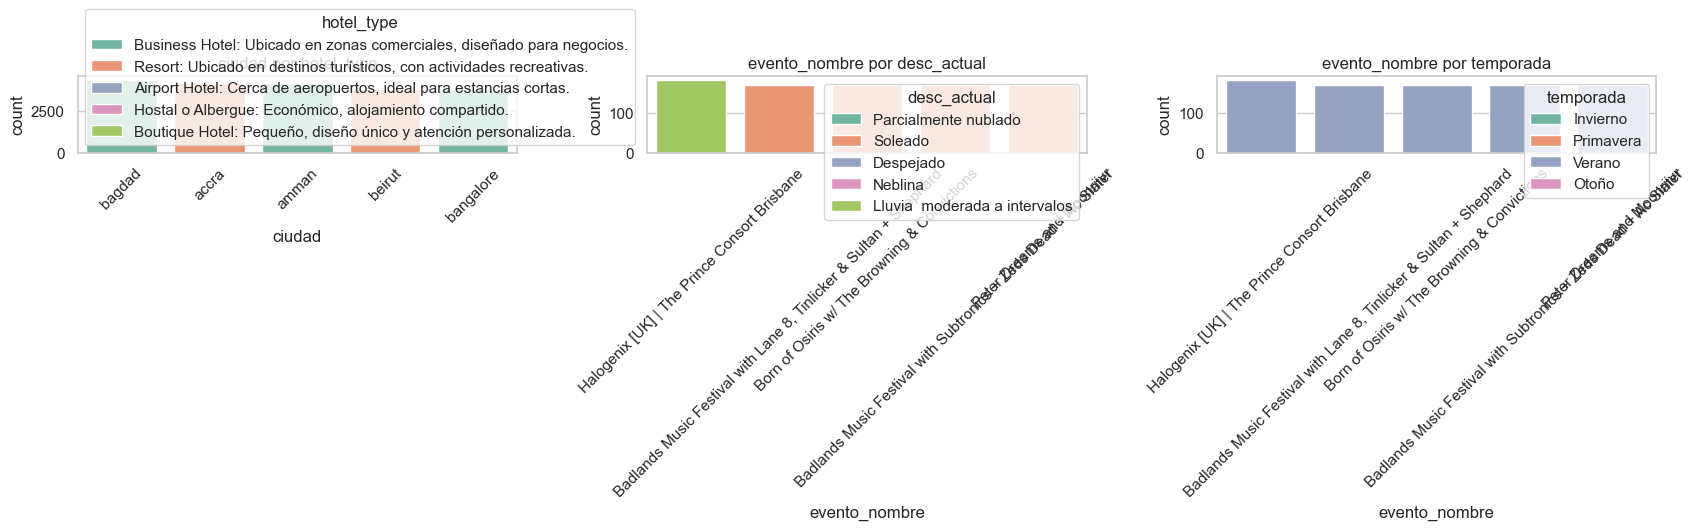

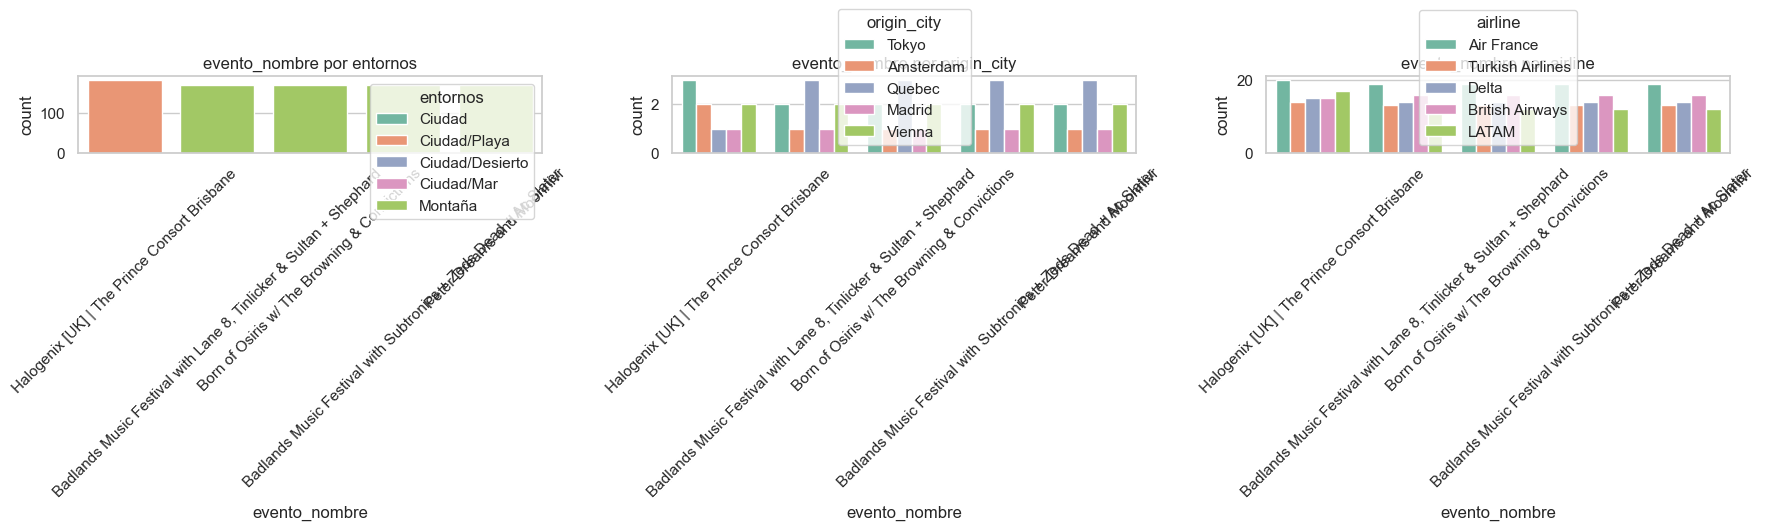

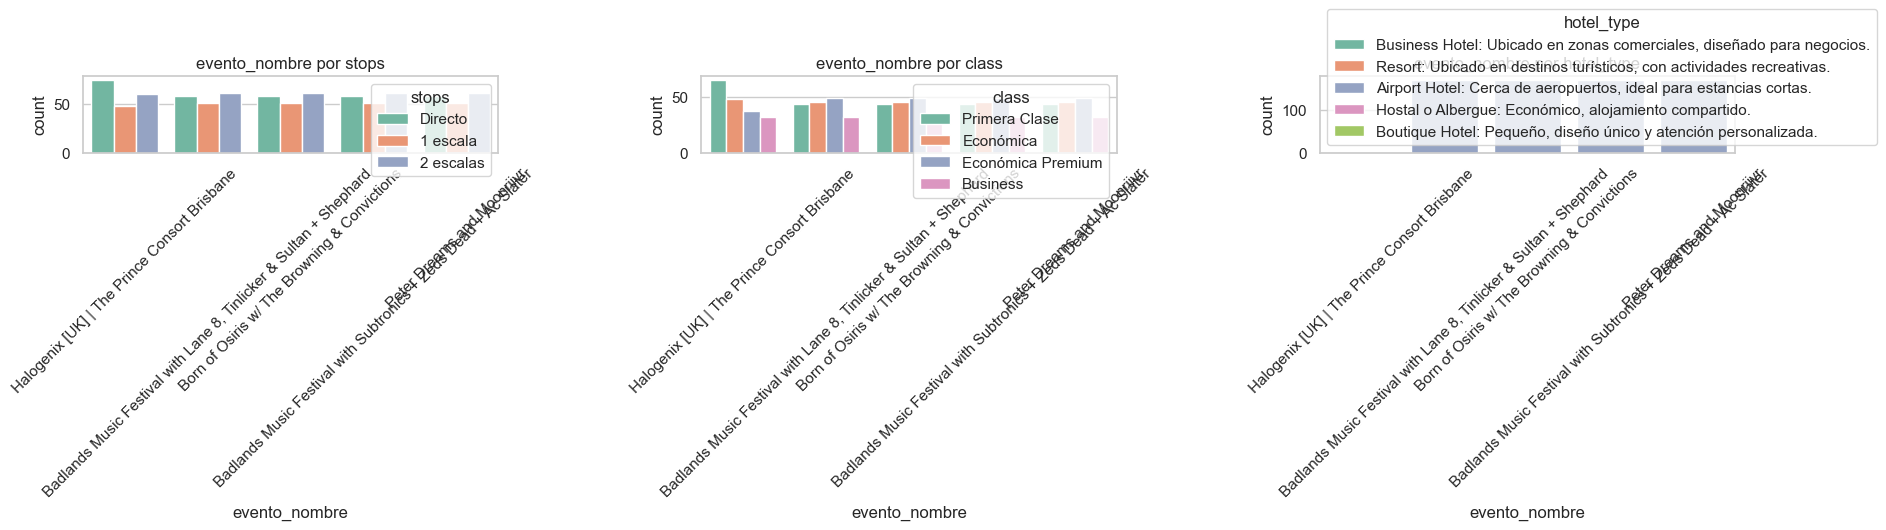

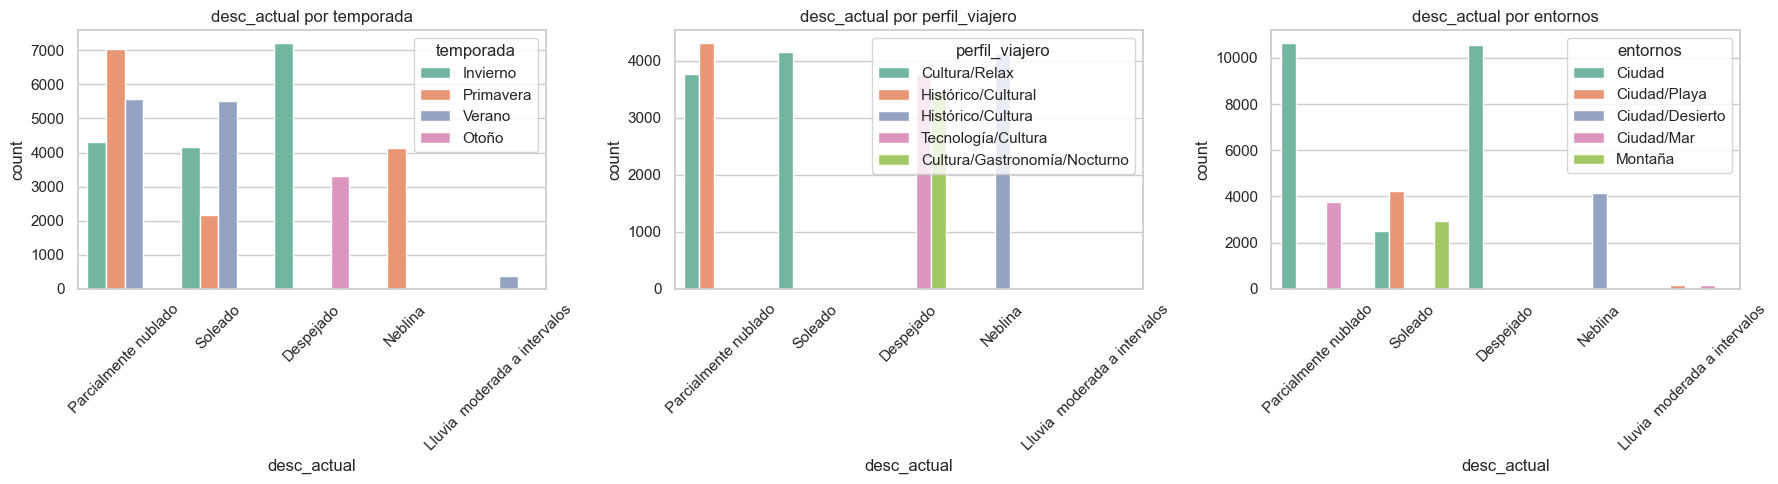

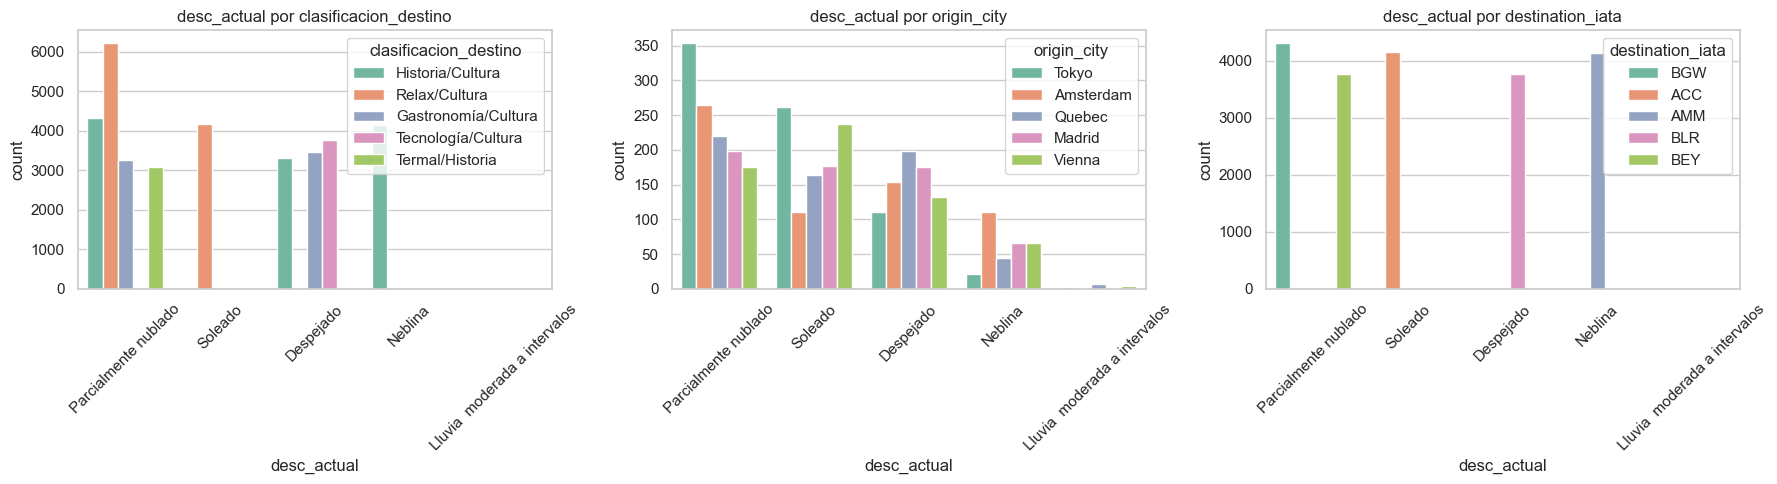

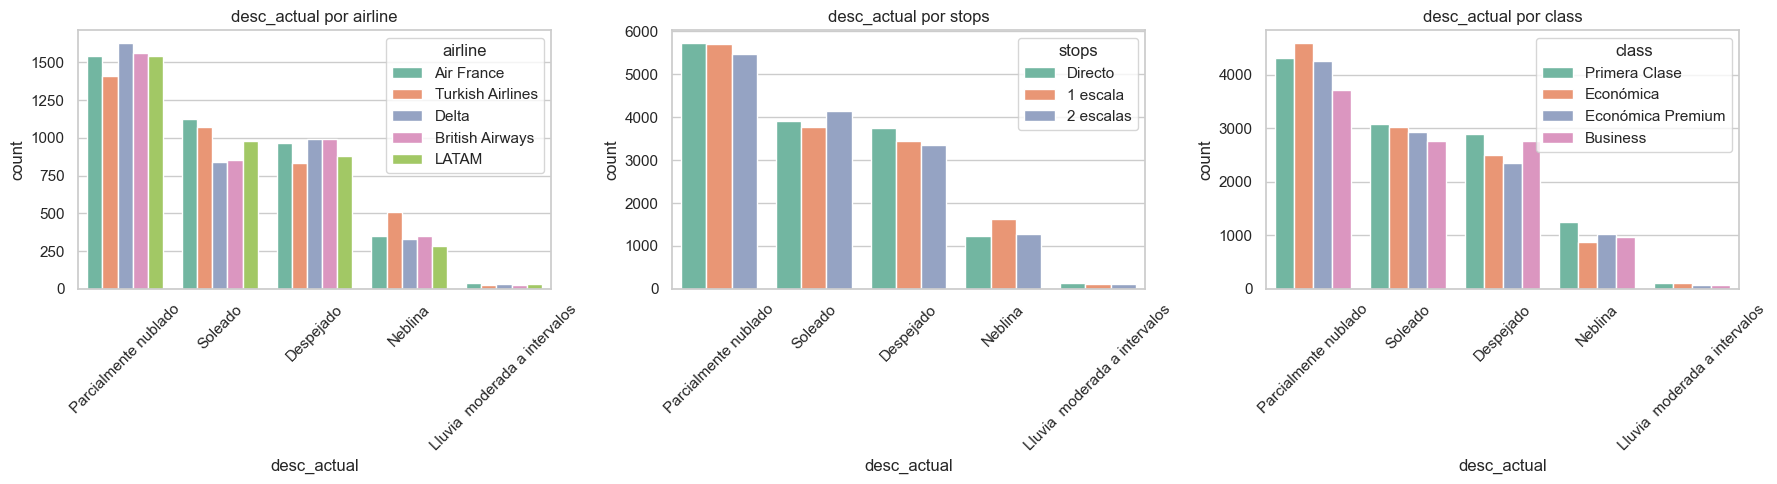

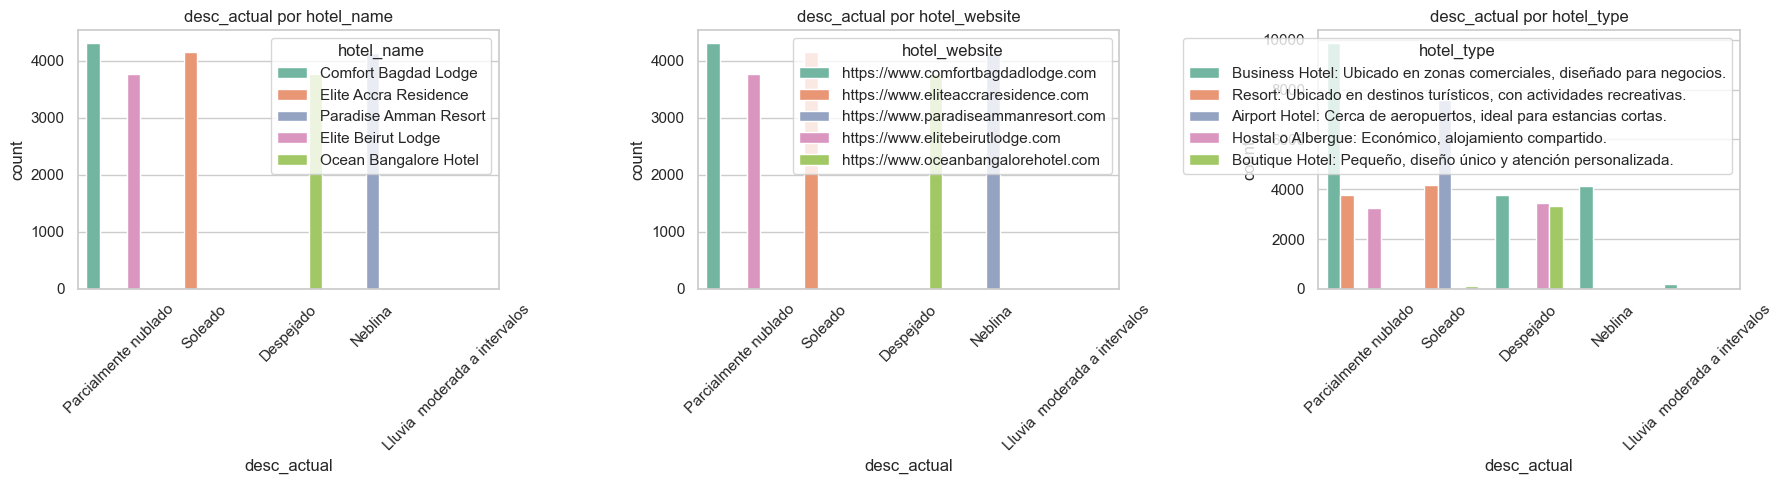

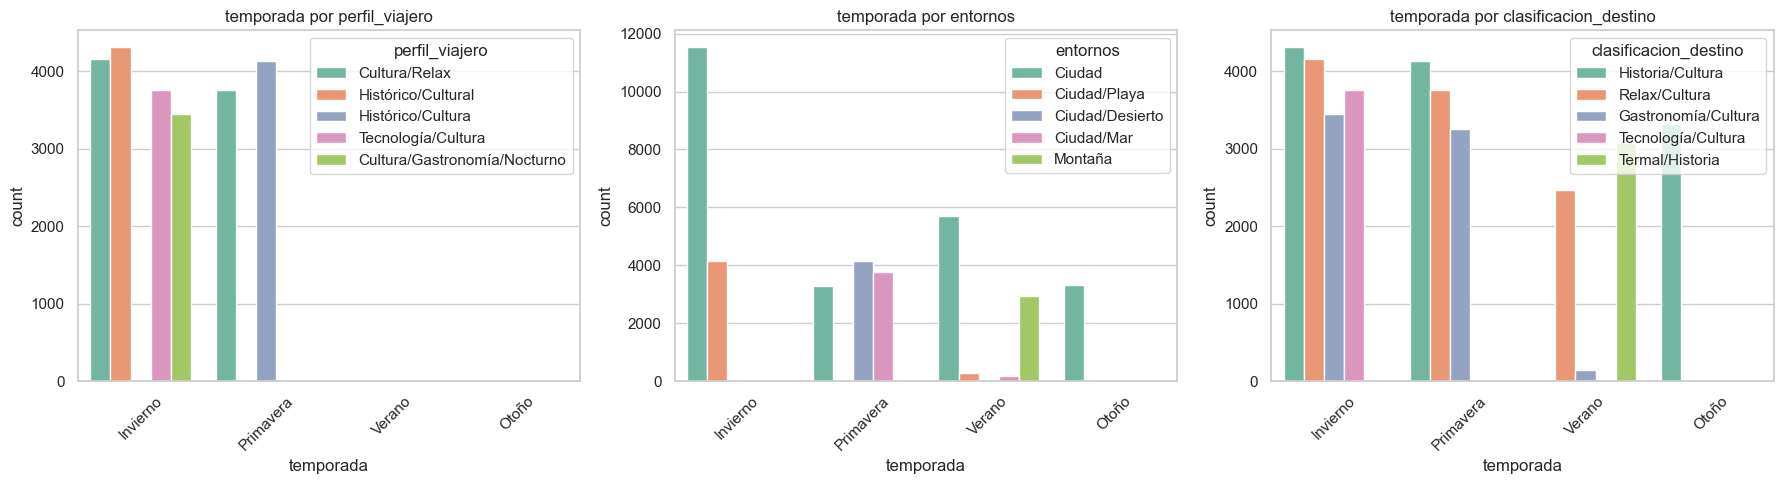

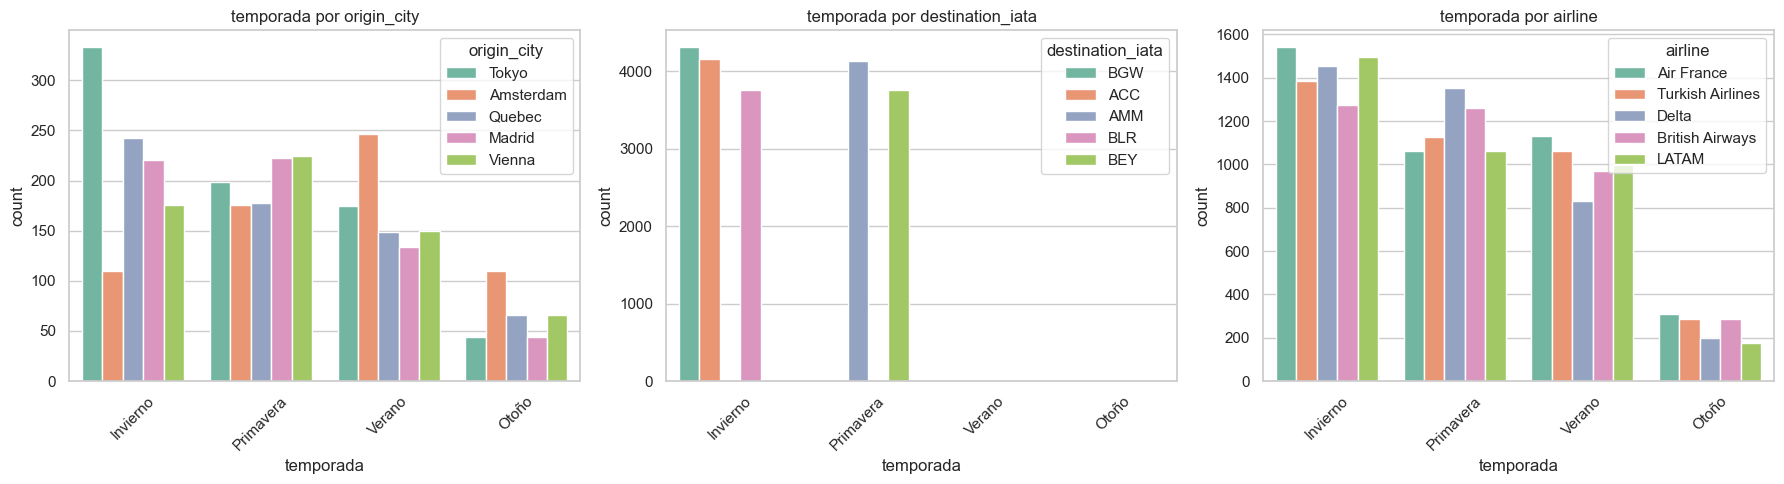

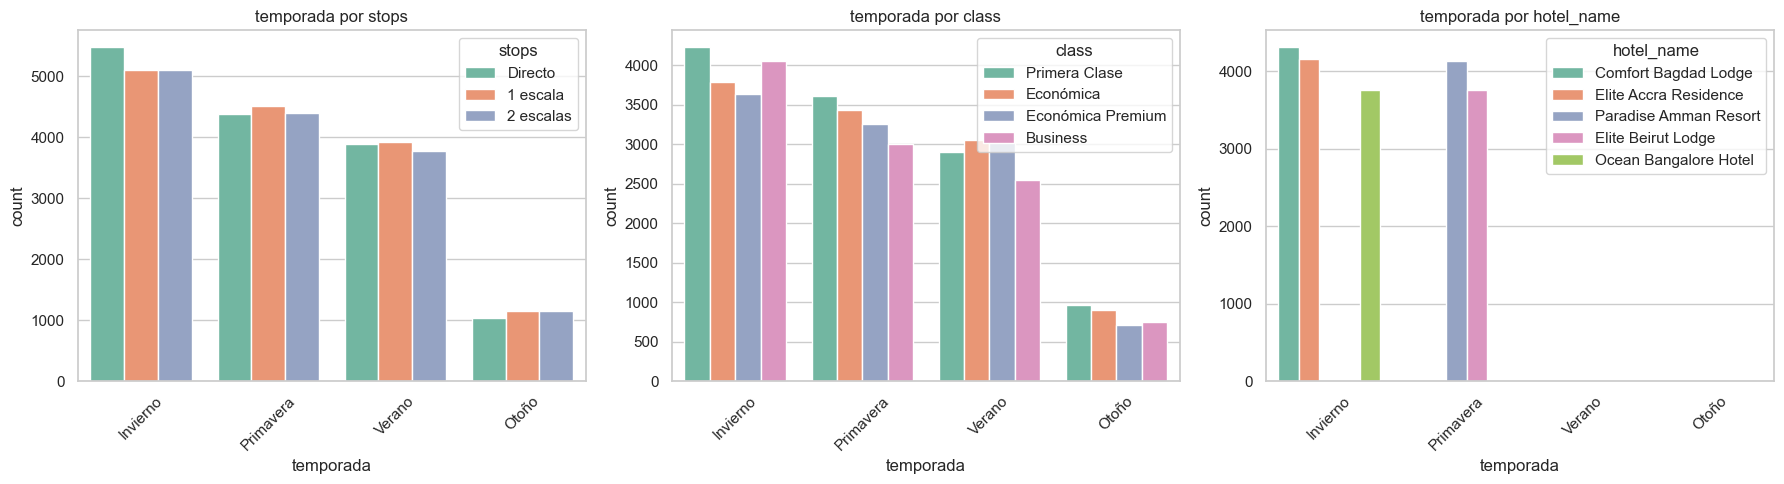

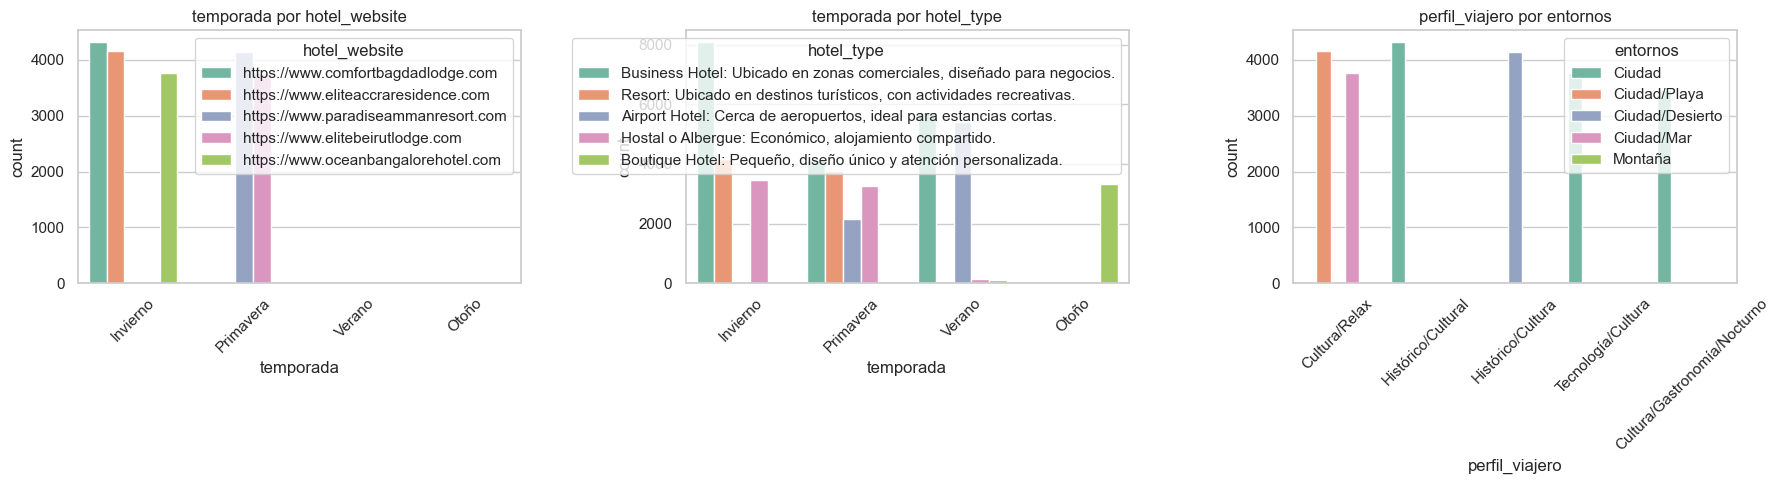

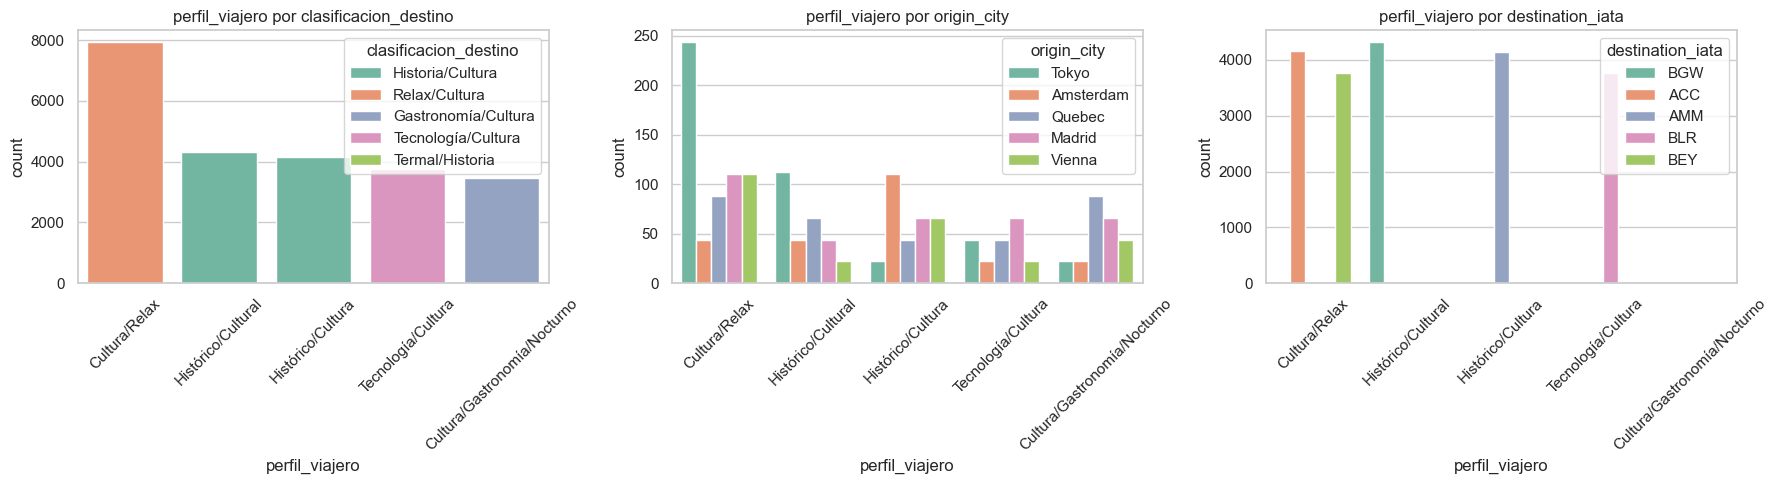

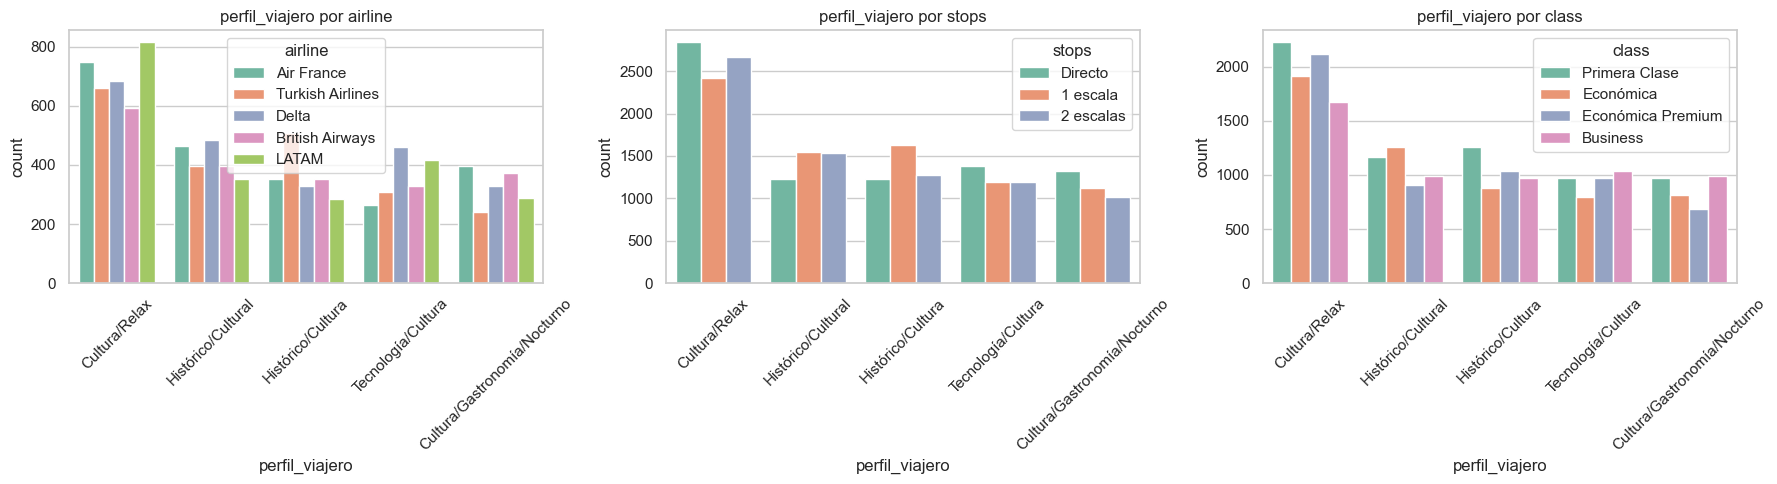

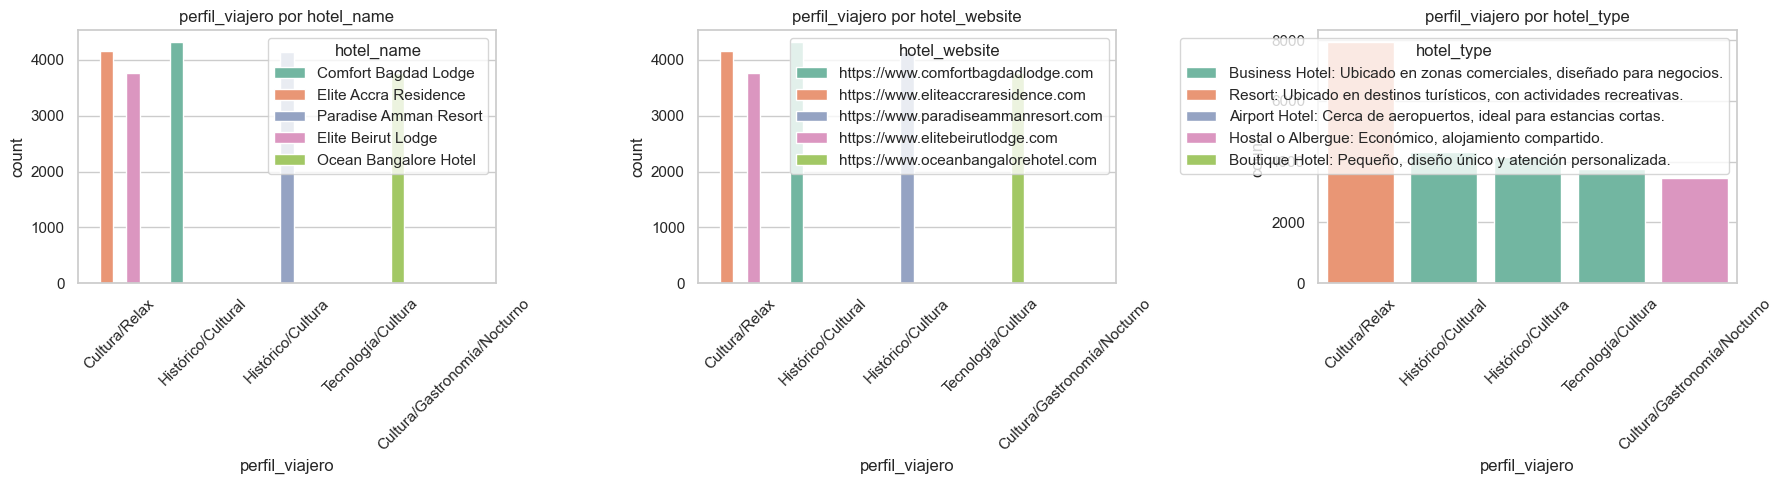

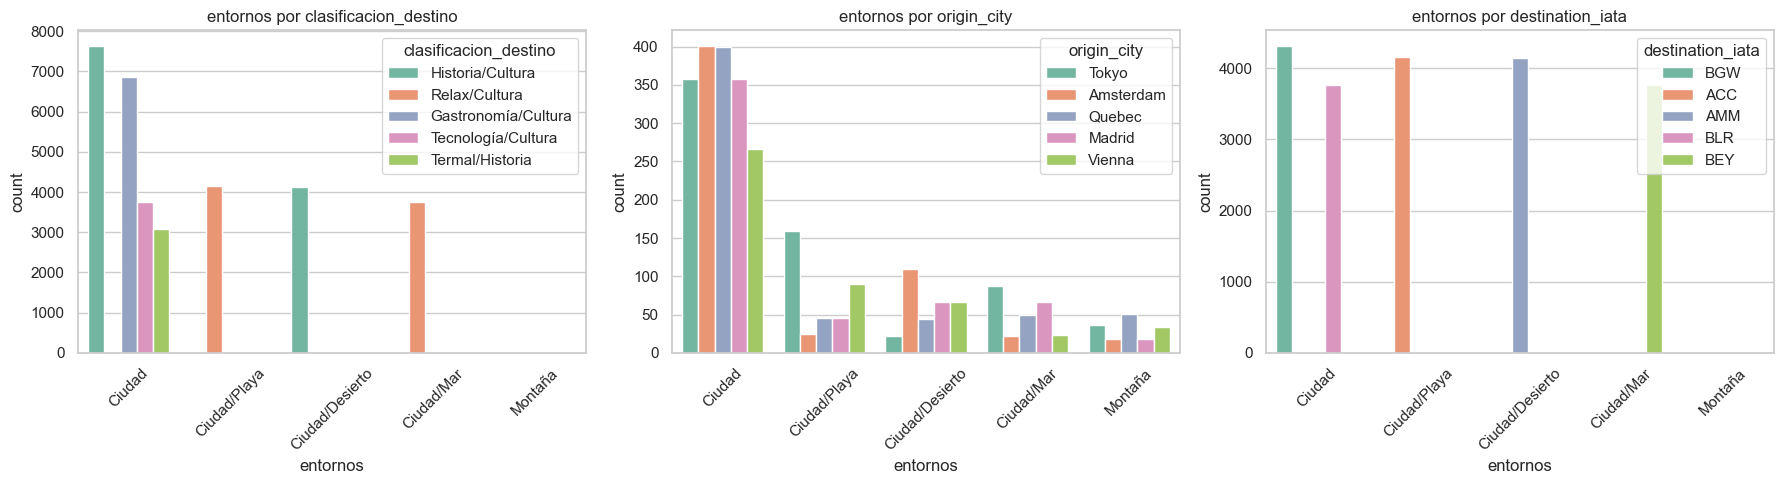

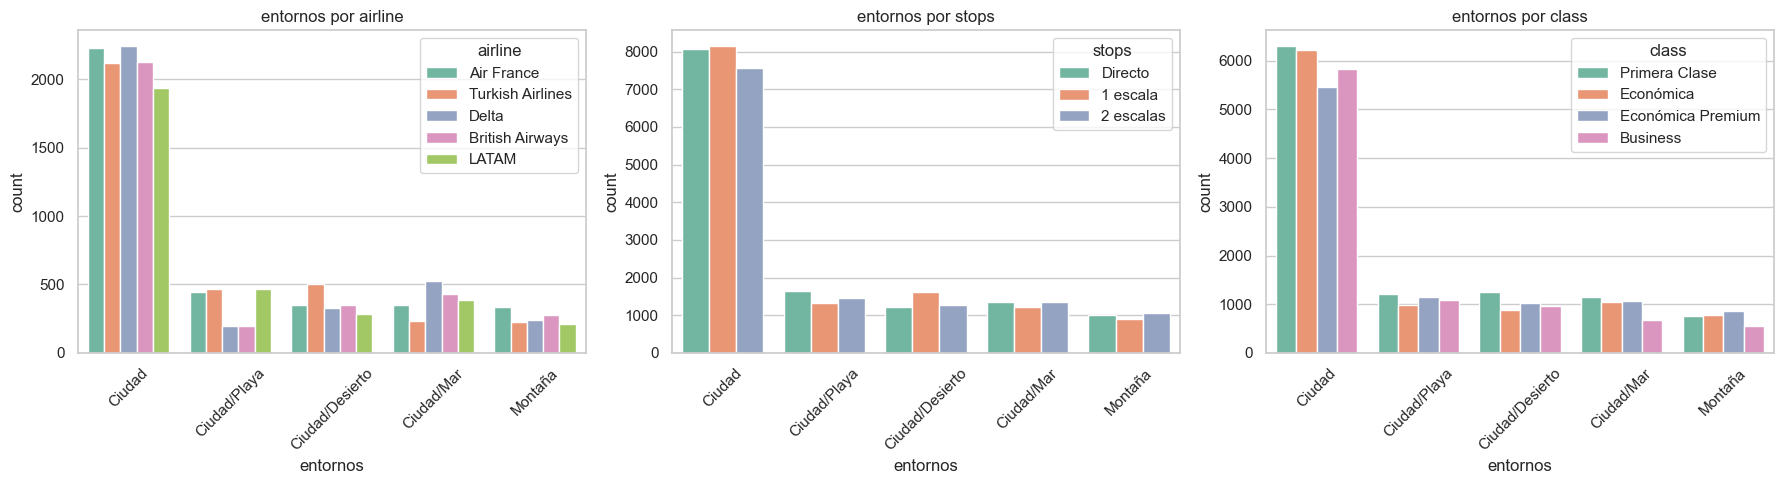

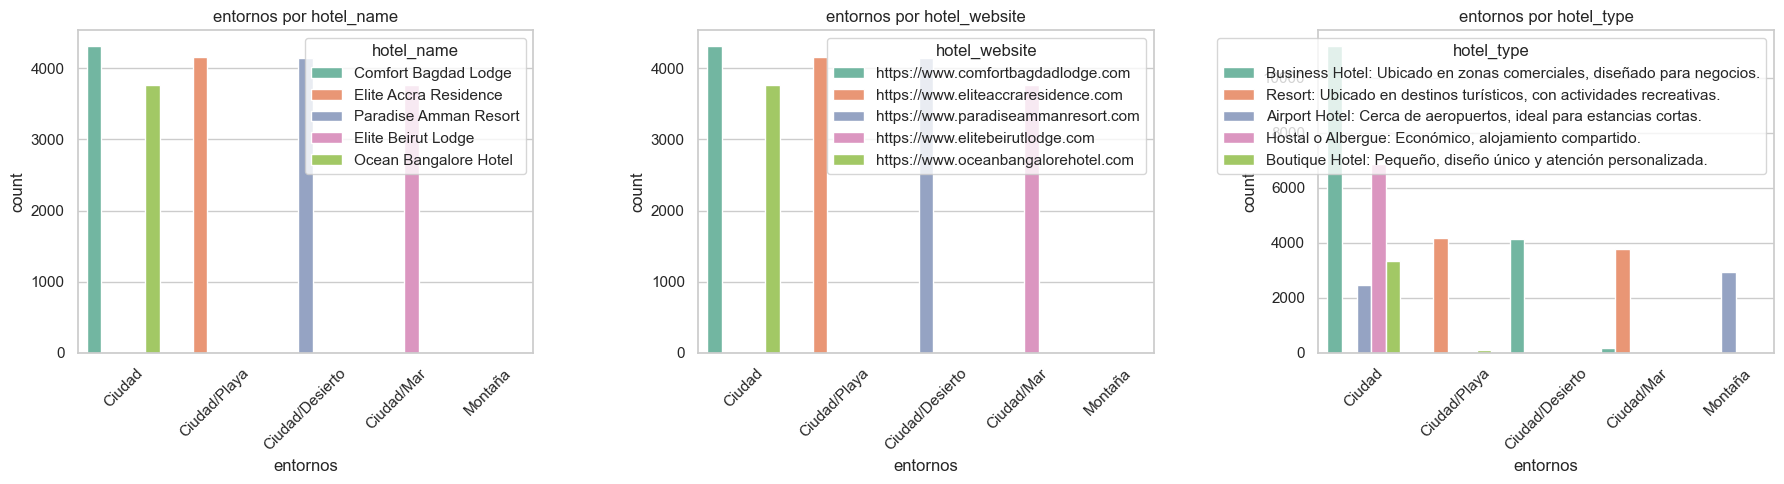

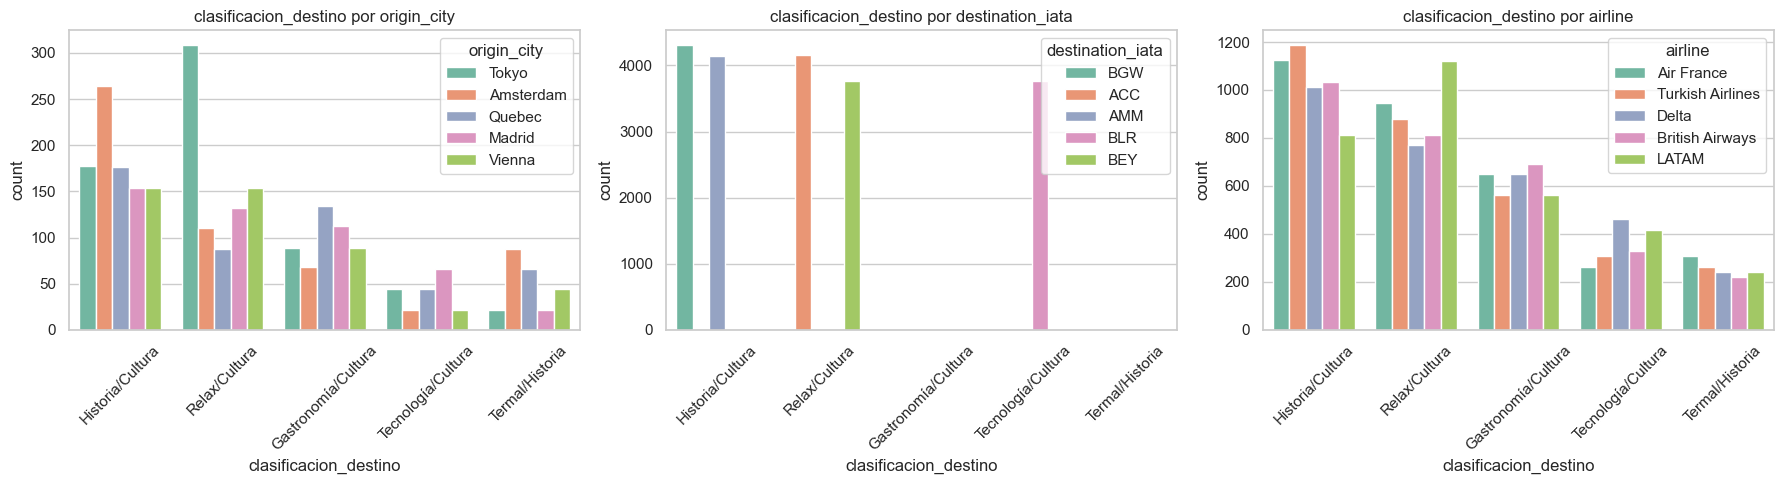

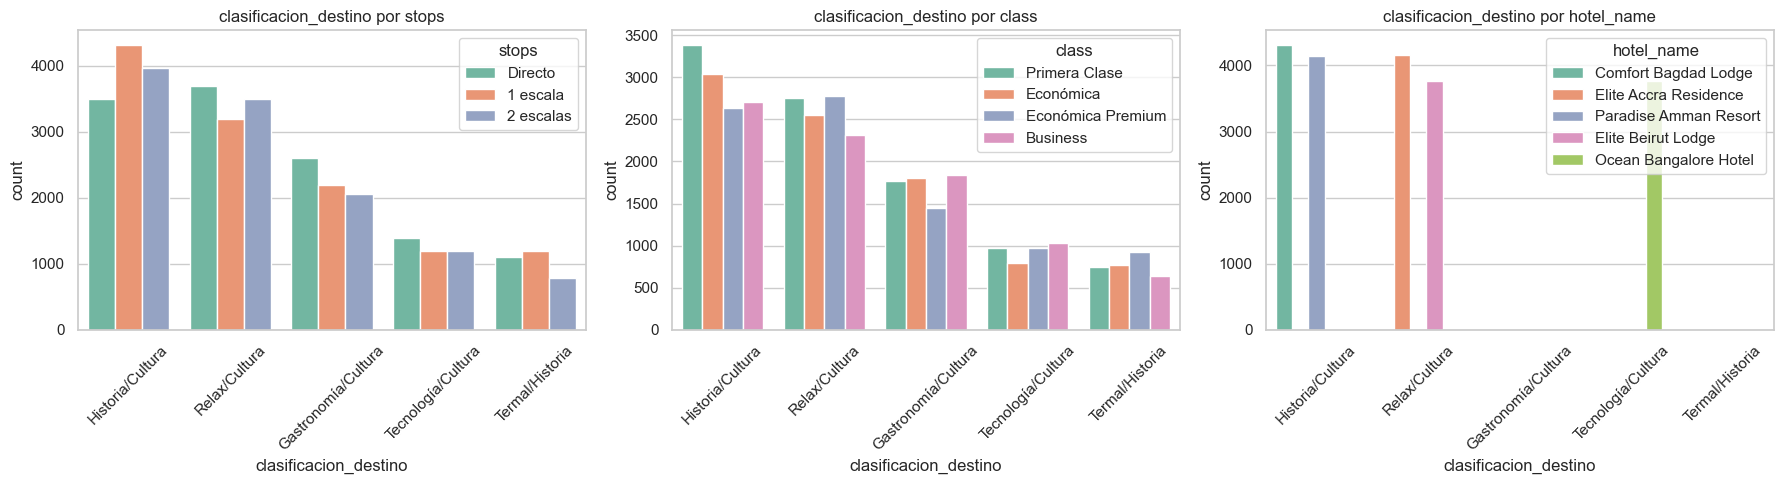

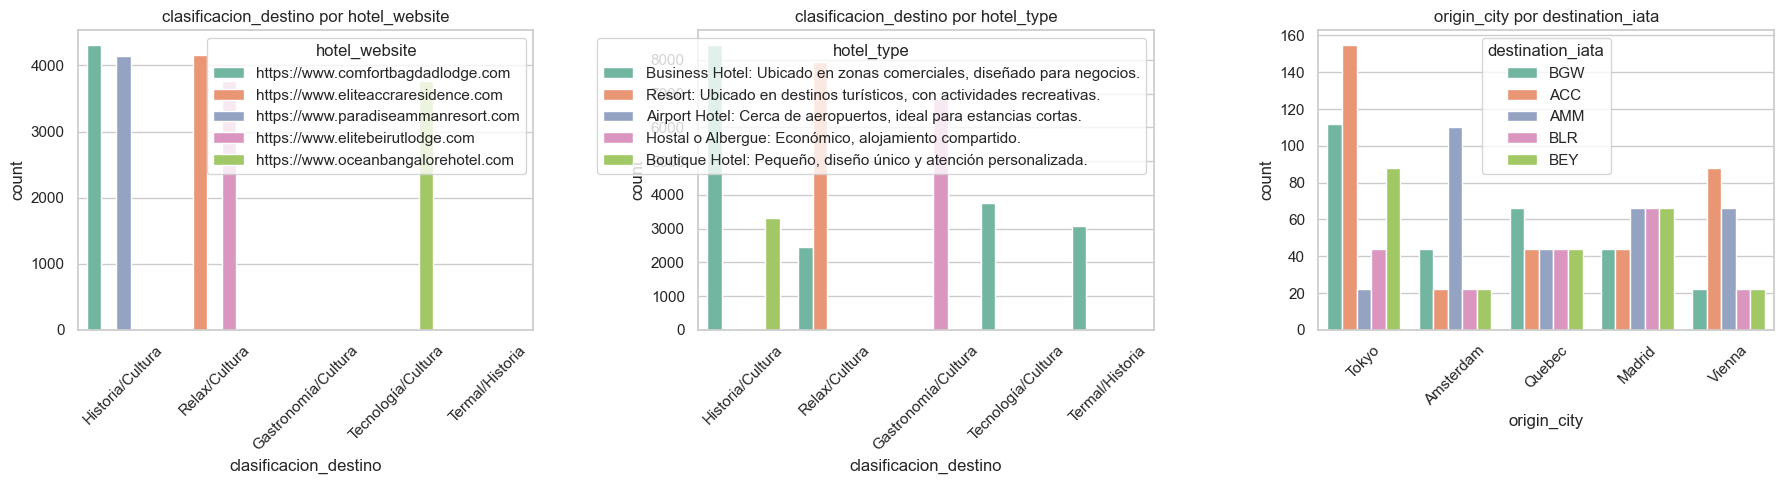

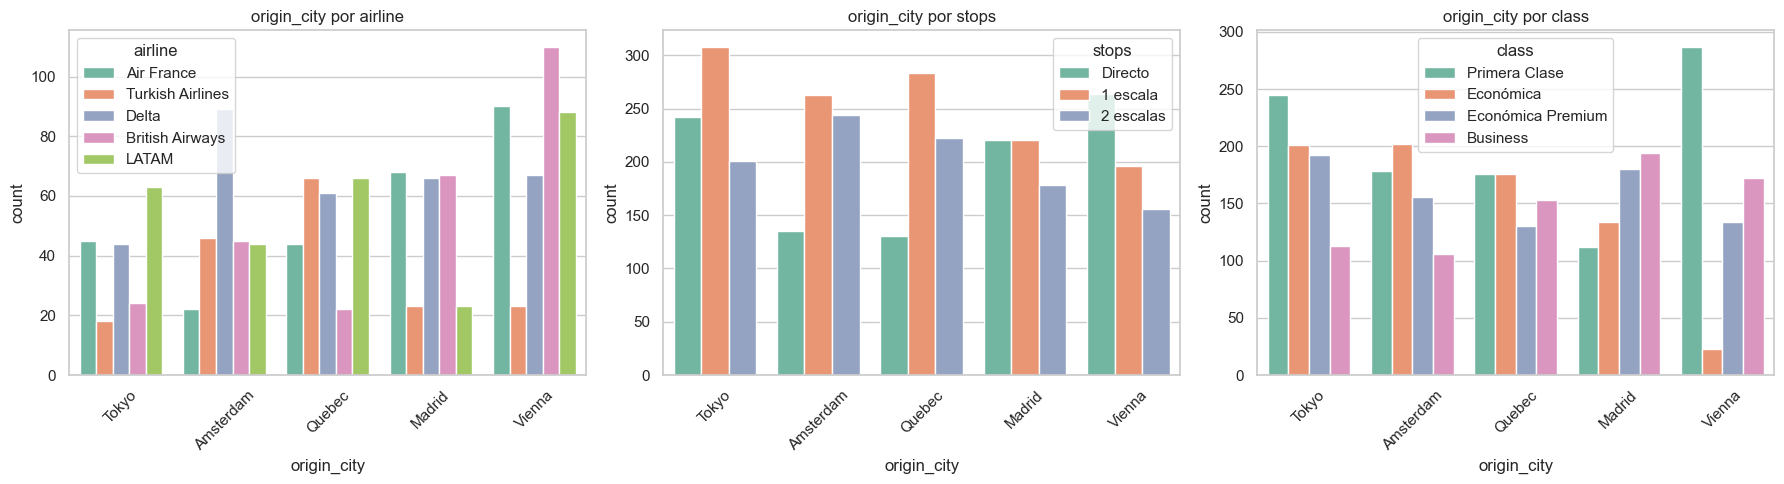

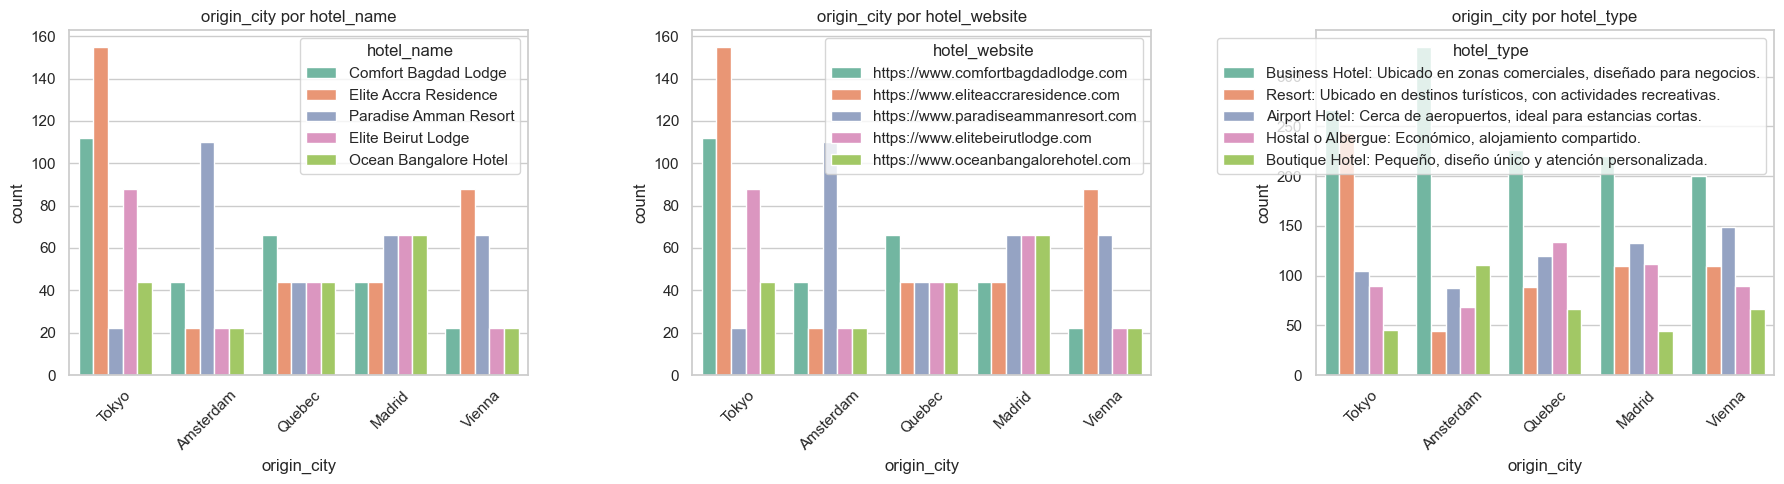

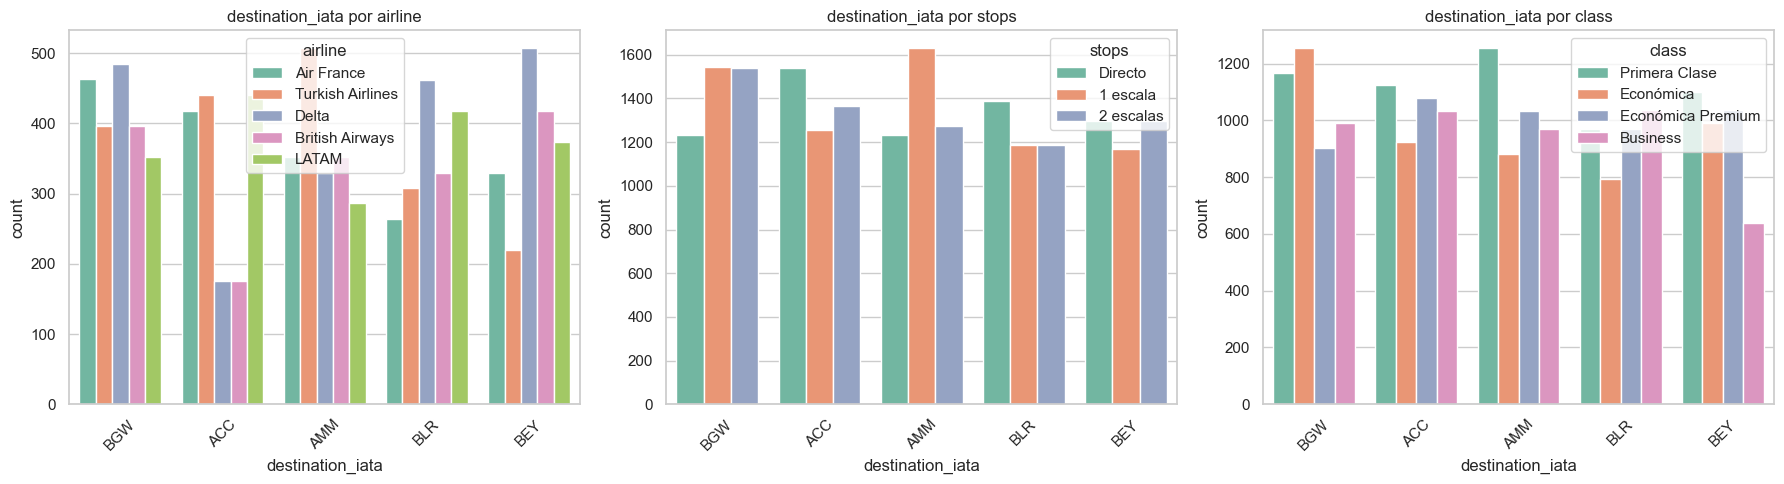

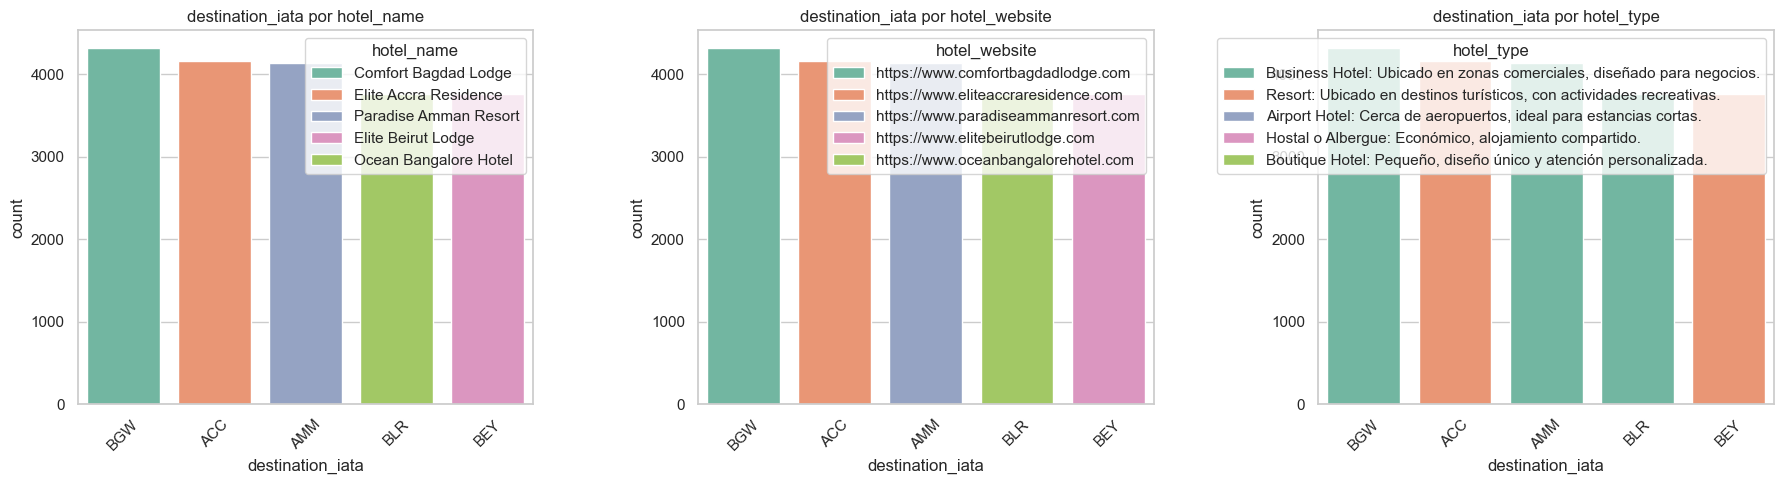

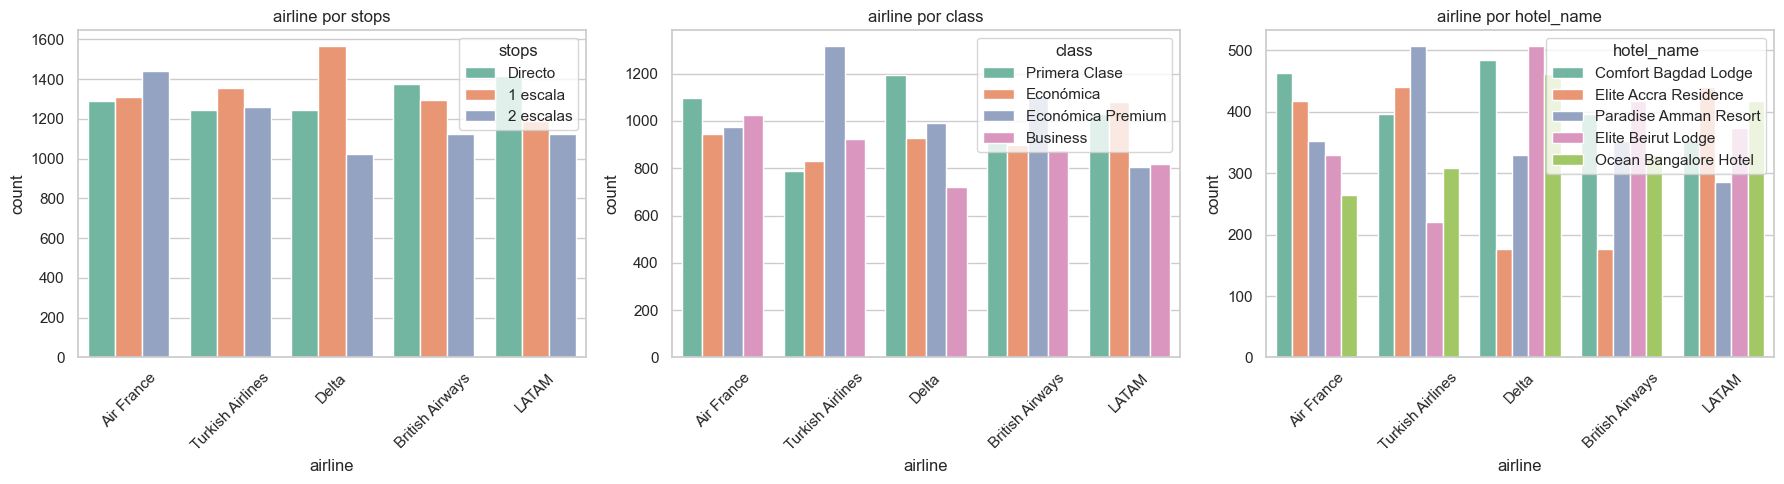

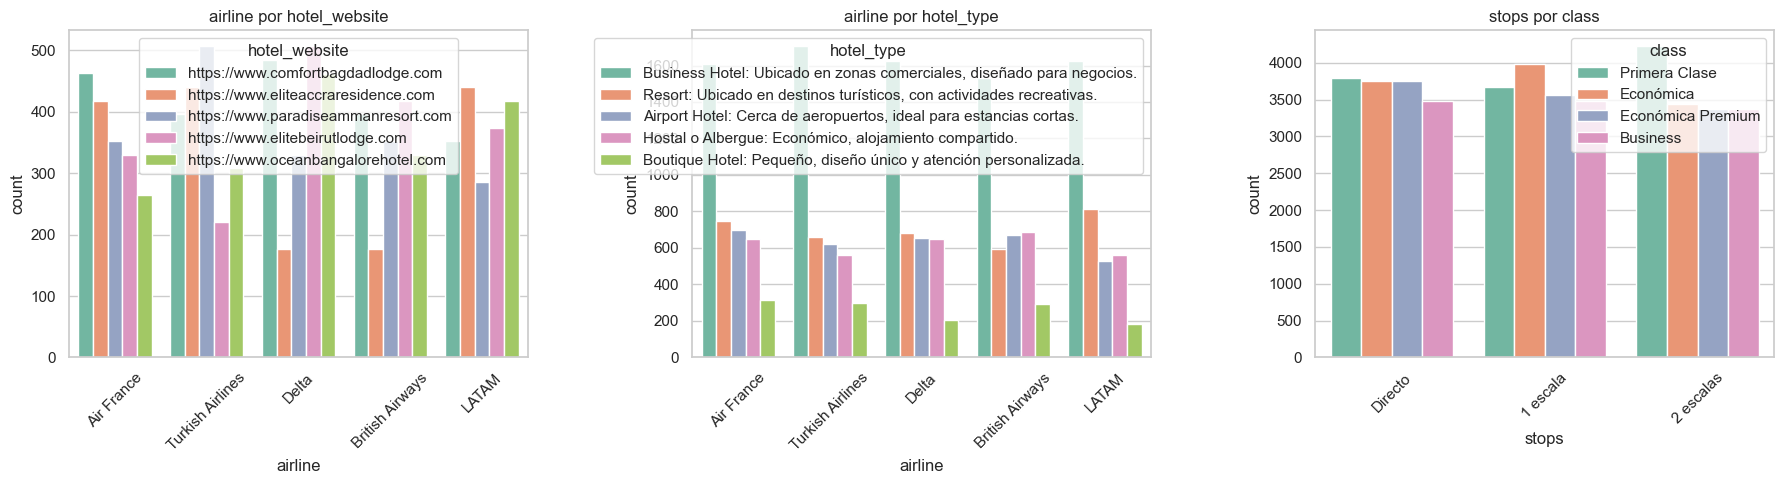

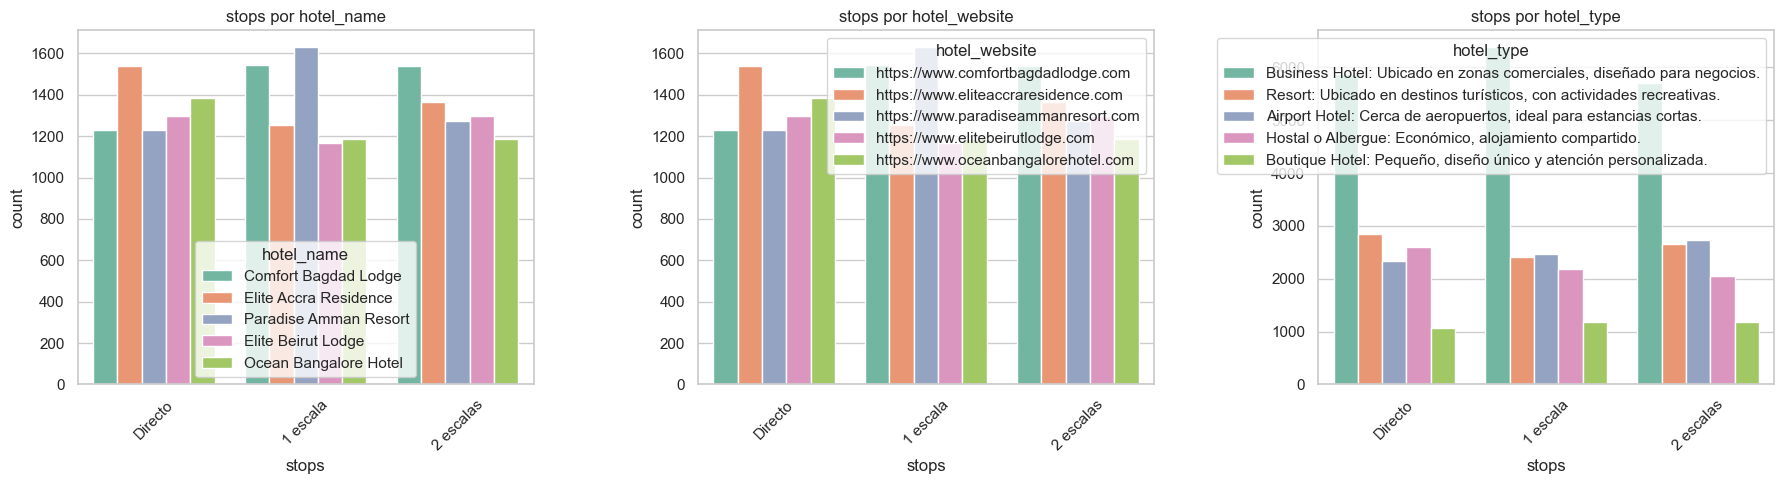

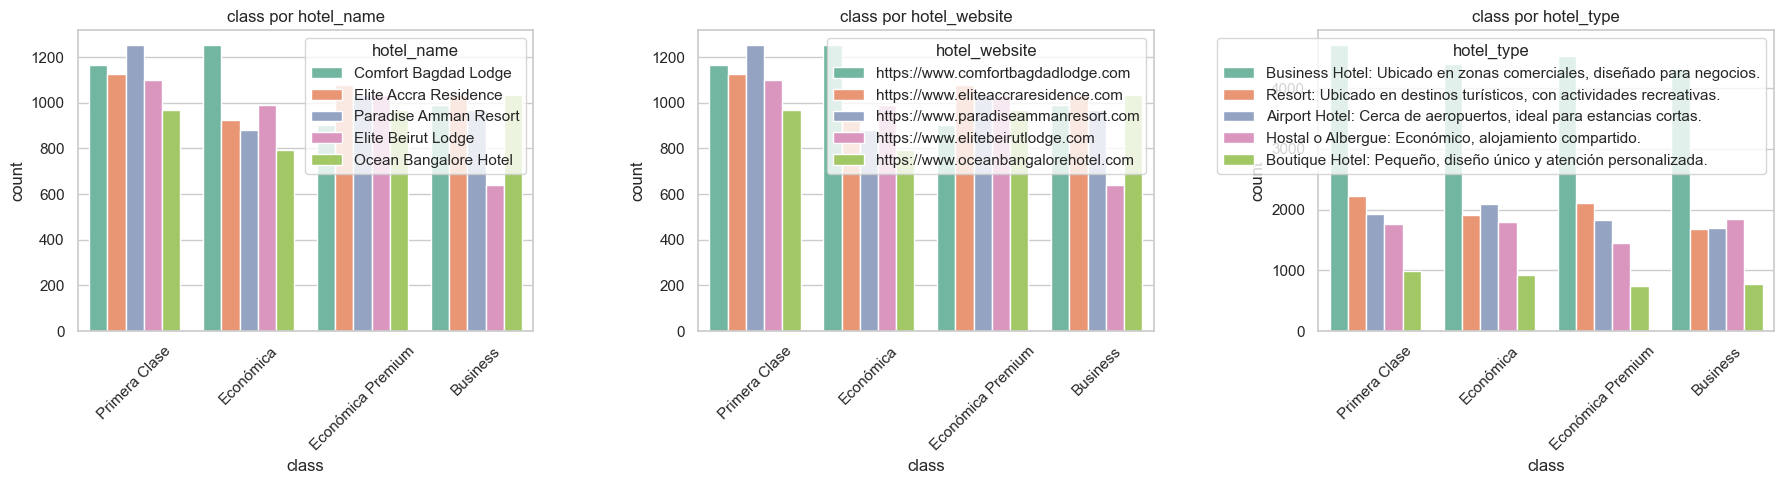

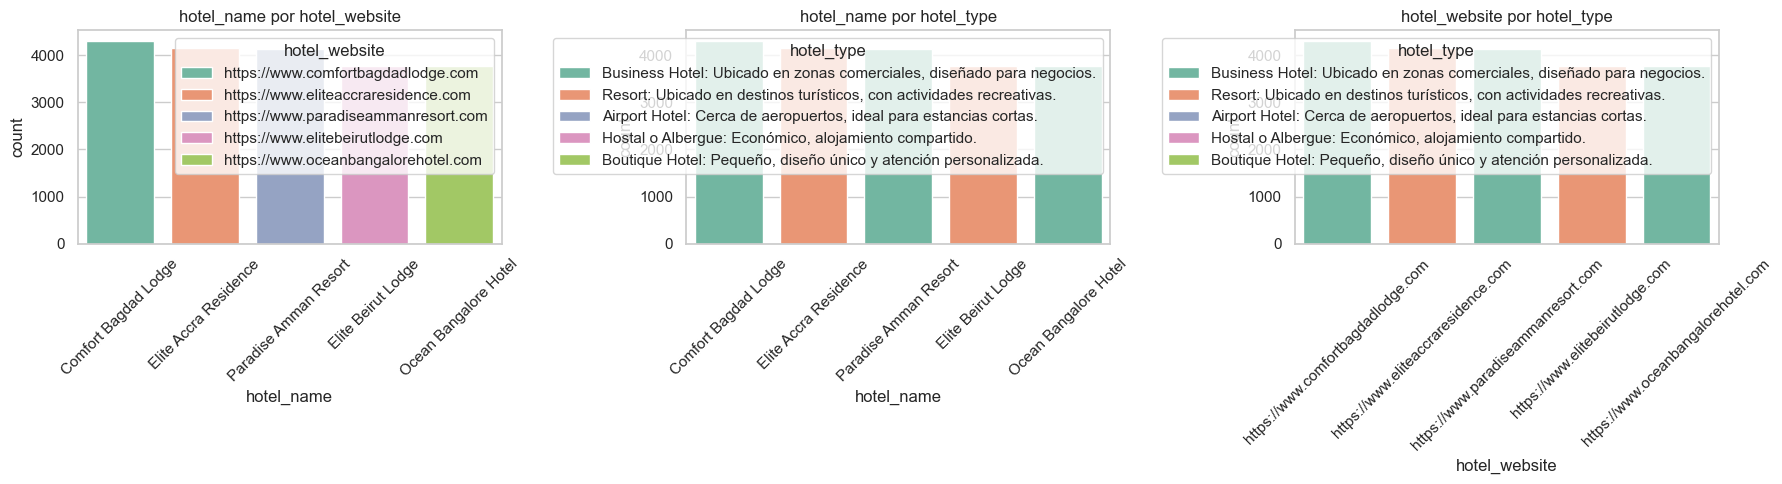

In [ ]:
bivariate_categorical_analysis(df)


#### Conclusiones del Análisis Bivariante Categórico

- **ciudad vs class**: Las clases de vuelo más frecuentes varían según la ciudad, reflejando preferencias regionales.
- **ciudad vs hotel_name**: Algunas ciudades concentran reservas en hoteles específicos, indicando destinos populares.
- **class vs evento_categoria**: Las clases más altas se asocian ligeramente con eventos de mayor categoría.
- **hotel_name vs evento_nombre**: Ciertos hoteles se relacionan con eventos específicos, lo que sugiere convenios o paquetes.
- **evento_categoria vs evento_desc**: Las descripciones de eventos coinciden con sus categorías, mostrando coherencia.
- **class vs hotel_type**: Las clases de vuelo más altas tienden a coincidir con tipos de hotel más exclusivos.

Conclusiones:

	•	Algunas combinaciones entre class de vuelo y stops muestran patrones marcados: la mayoría de los vuelos de clase económica son directos, mientras que las clases más altas tienen más escalas, posiblemente debido a rutas largas.
	•	También se identificó que ciertos hotel_type están más presentes en una ciudad que en otra, lo que refleja la diferencia en el perfil turístico entre Accra y Zurich.


### 3.3 Combinaciones de la clase con varias predictoras

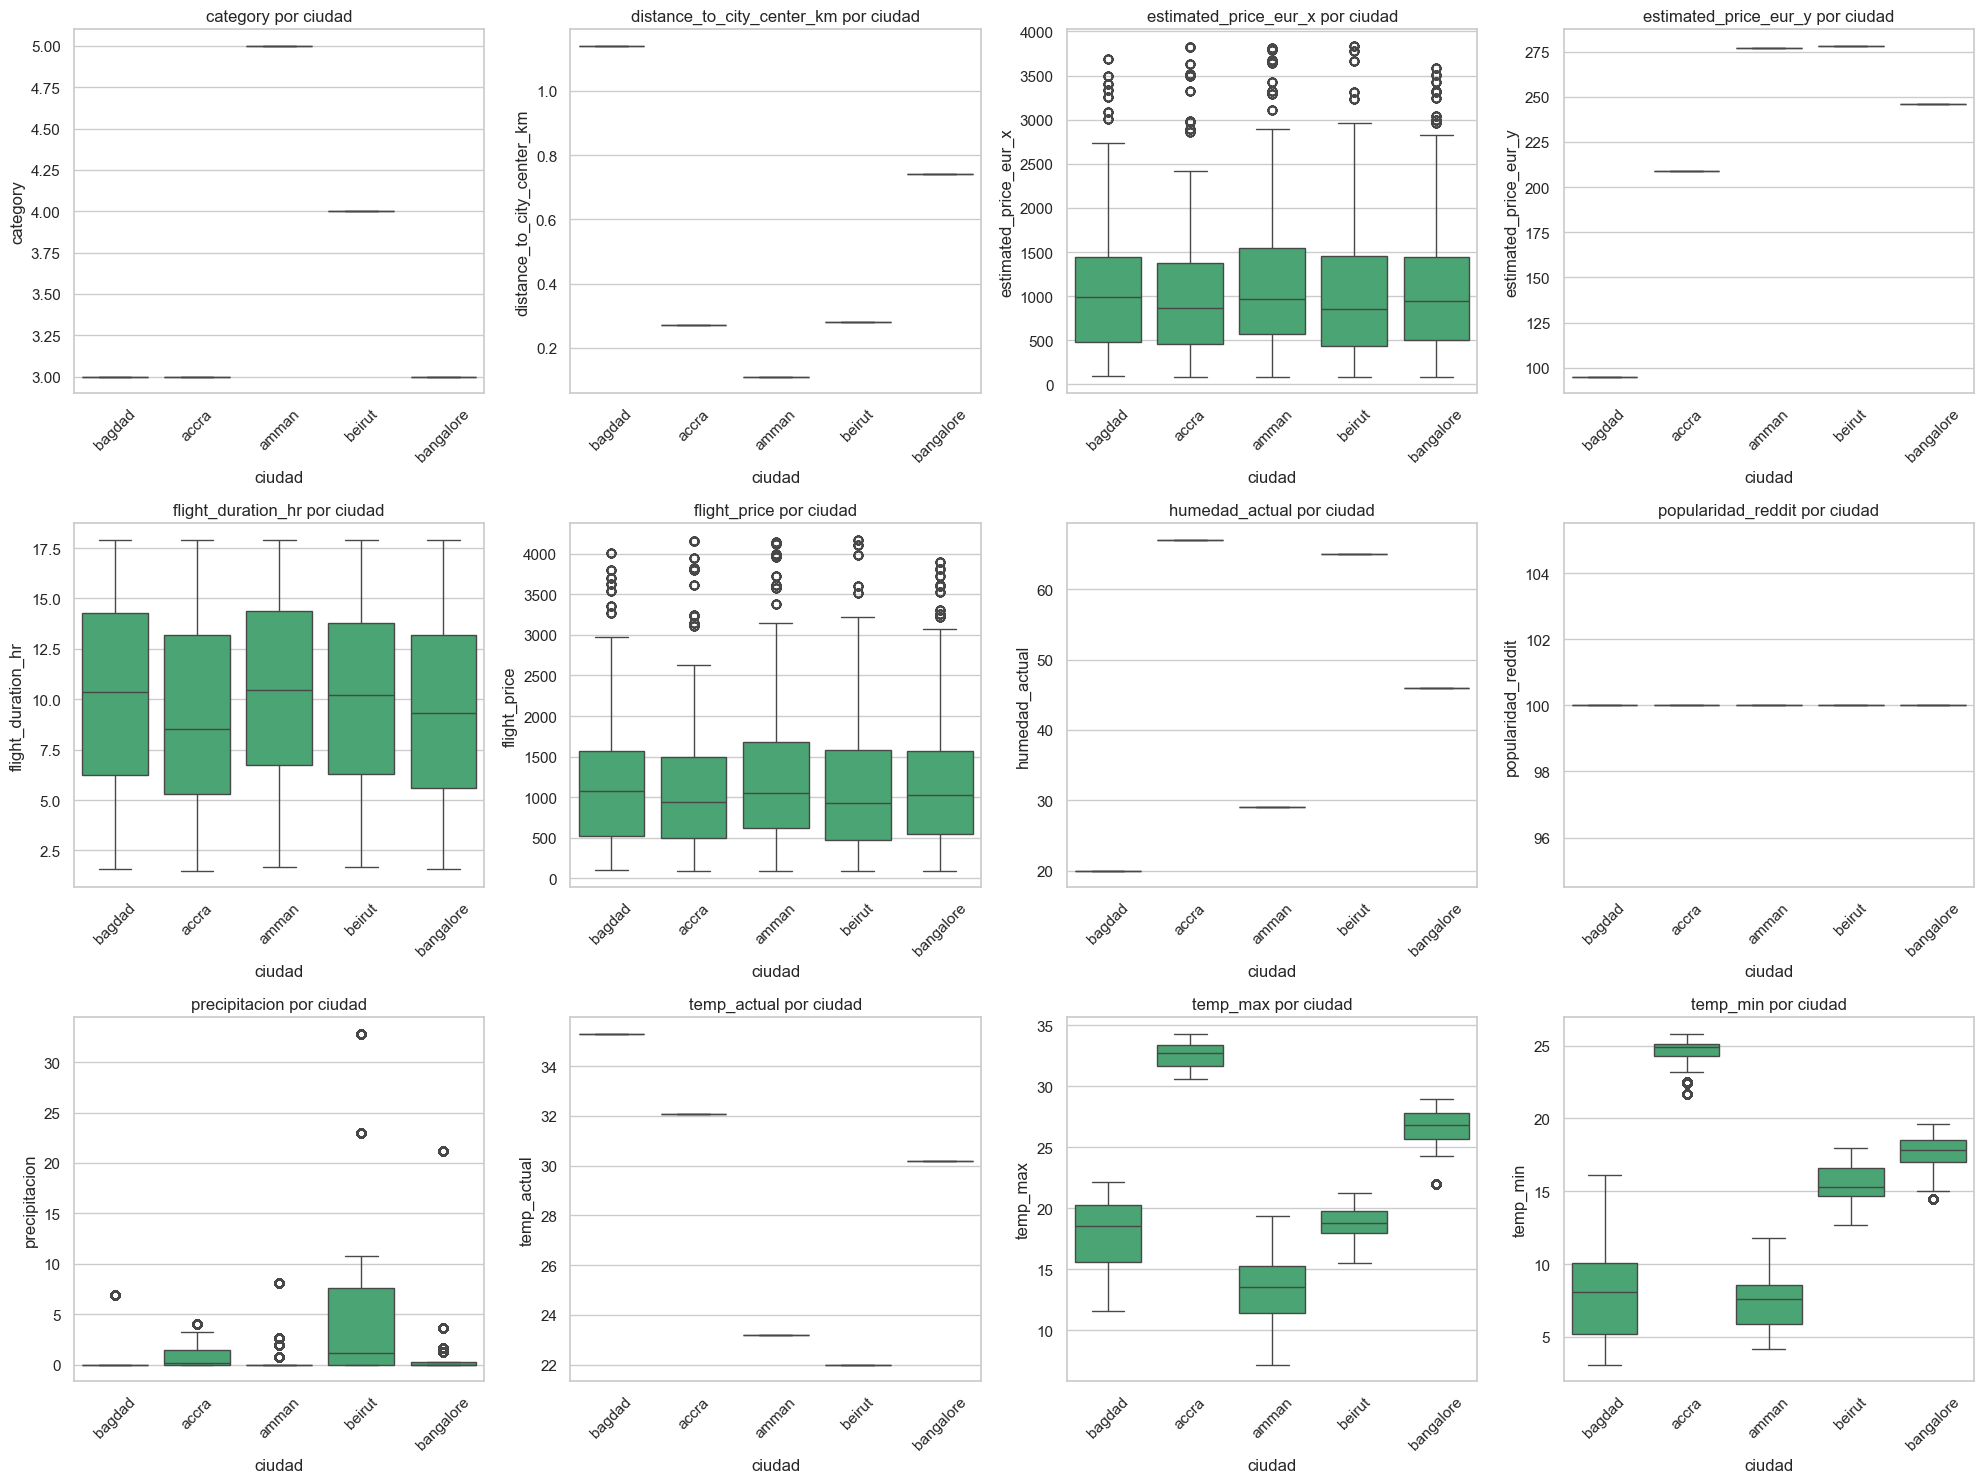

In [ ]:
class_predictor_analysis(df)

Conclusiones:

Al relacionar la variable objetivo con atributos como producto o canal_venta, se evidenció que algunos productos tienen mayores tasas de conversión, lo cual es clave para futuros modelos de clasificación o segmentación.

	•	Al analizar la clase de vuelo (class) en relación con otras variables, se observó:
	•	Los vuelos con precios más altos tienden a corresponder a clases superiores, como “Business” o “Primera Clase”.
	•	Los usuarios que eligen airport hotel se asocian más con clases económicas, posiblemente viajeros de negocios o escalas cortas.
	•	Las fechas cercanas a fin de año tienen una mayor proporción de vuelos caros.

### 3.4 Análisis de correlaciones

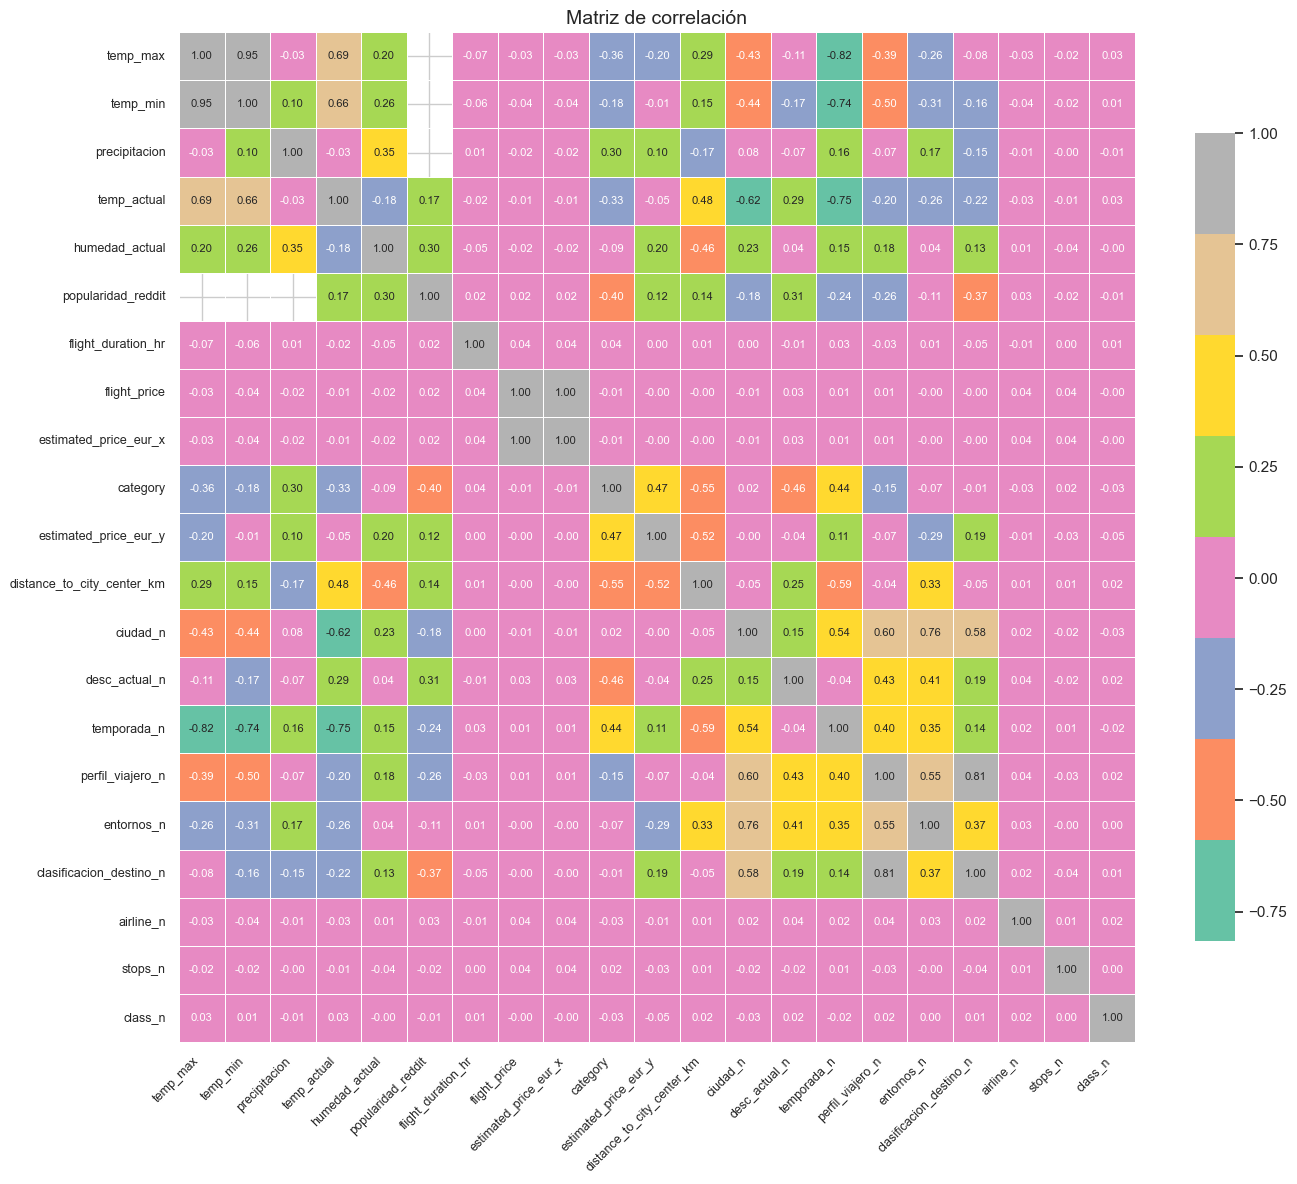

In [ ]:
correlation_analysis(df)

Conclusiones:

	•	Variables como estimated_price_usd, estimated_price_eur_x y estimated_price_eur_y están fuertemente correlacionadas (>0.95), lo que sugiere eliminar duplicadas para evitar multicolinealidad.
	•	temp_actual tiene una leve correlación negativa con flight_price, lo que puede indicar que el clima cálido no influye en el precio del vuelo.
	•	humedad_actual no muestra correlación significativa con ninguna otra variable numérica.



### 3.5 Categórico-numérico

In [ ]:
categorical_numerical_correlation(df)

c:\Users\PilarHernández\OneDrive - COLEGIO DE REGISTRADORES DE LA PROPIEDAD Y MERCANTILES ESPAÑA\Escritorio\BOOTCAMP\MI REPOSITORIO - EJERCICIOS\Predicccion_agencia_de_viajes_proyecto\src\Auto_EDA.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\PilarHernández\OneDrive - COLEGIO DE REGISTRADORES DE LA PROPIEDAD Y MERCANTILES ESPAÑA\Escritorio\BOOTCAMP\MI REPOSITORIO - EJERCICIOS\Predicccion_agencia_de_viajes_proyecto\src\Auto_EDA.py:261: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
c:\Users\PilarHernández\OneDrive - COLEGIO DE REGISTRADORES DE LA PROPIEDAD Y MERCANTILES ESPAÑA\Escritorio\BOOTCAMP\MI REPOSITORIO - EJERCICIOS\Predicccion_agencia_de_viajes_proyecto\src\Auto_E

### Análisis de Outliers

- **`flight_price`**: Se identificaron outliers con valores superiores a **5000 EUR**, muy por encima del percentil 99.
- **`estimated_price_usd`**: Se detectaron precios hoteleros anómalos superiores a **1000 USD**, especialmente en **Zurich**.
- **`distance_to_city_center_km`** y **`fligth_duration_hr`**: Presentan distribuciones con **colas derechas** y varios valores fuera del rango normal, lo que sugiere viajes excepcionales o posibles errores.
- **`popularidad_reddit`** y **`precipitacion`**: Muestran valores inusualmente altos. En particular, `precipitacion` presenta una gran **polaridad**, lo que podría estar afectando su distribución general.
- **`temp_max`** y **`temp_min`**: Contienen valores extremos, incluyendo **temperaturas negativas** que podrían no tener sentido según el contexto geográfico del destino.
- **`Clasificacion_destino_n`** y **`entornos_n`**: Contienen valores que se alejan significativamente de la media, posiblemente por **errores de codificación** o categorías extremadamente poco frecuentes.
- **Tratamiento de outliers**: Se aplicó **Winsorización** (reemplazo por percentiles), conservando la estructura general de los datos sin eliminar valores extremos que pudieran ser válidos.


Conclusiones: 	
    
    •	La media de flight_price varía claramente entre clases de vuelo:
	•	Económica: ~400-800 EUR
	•	Business: ~1000-2000 EUR
	•	Primera Clase: >3000 EUR
	•	hotel_type también impacta en el estimated_price_usd, donde los “Resorts” y “Luxury Hotels” tienen precios mucho más elevados.
	•	El precio medio del hotel es ligeramente mayor en Zurich que en Accra, lo que es coherente con el costo de vida.


## 4. Análisis de toda la data en una

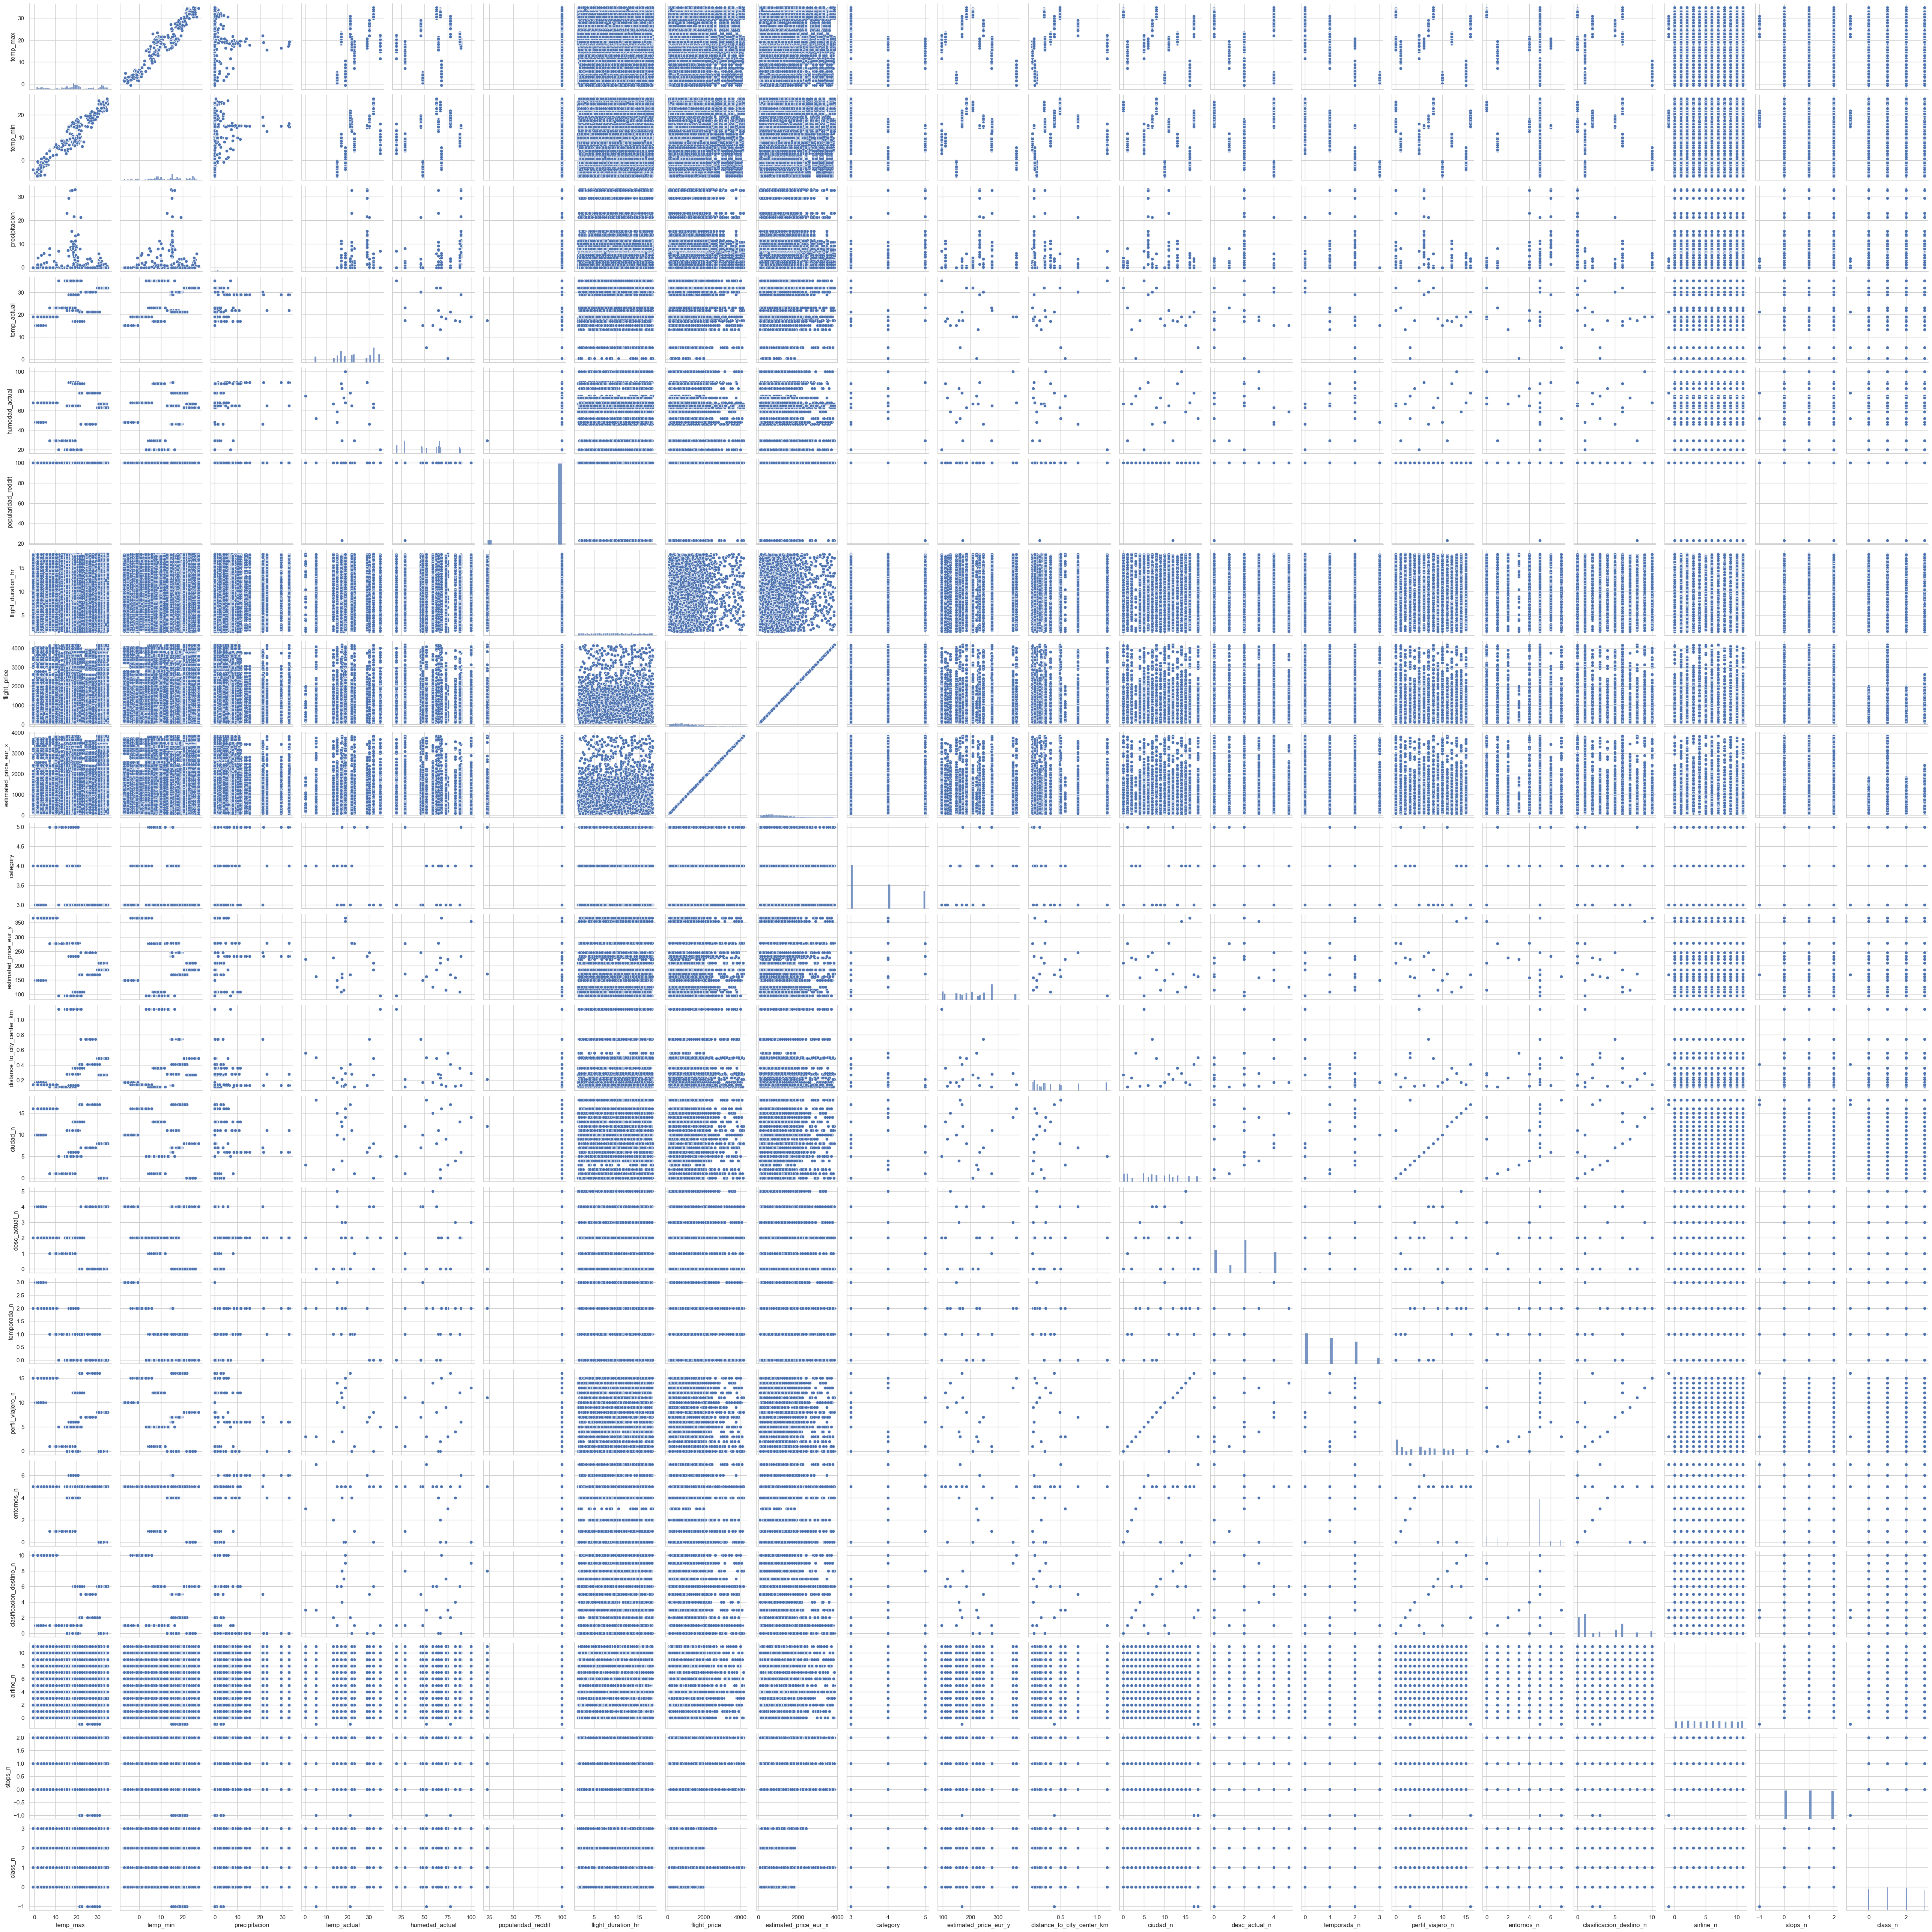

In [ ]:
pairplot_analysis(df)


### Conclusiones del Análisis Bivariante

1. **temp_max vs temp_min**: Alta correlación positiva, indicando que las temperaturas máximas y mínimas tienden a moverse juntas.
2. **temp_max vs temp_actual**: Correlación positiva moderada, sugiriendo que la temperatura actual está influenciada por la temperatura máxima.
3. **temp_max vs humedad_actual**: Baja correlación, indicando que la temperatura máxima no está fuertemente relacionada con la humedad actual.
4. **temp_max vs flight_price**: Baja correlación, sugiriendo que la temperatura máxima no afecta significativamente el precio del vuelo.
5. **temp_max vs estimated_price_eur_x**: Baja correlación, indicando que la temperatura máxima no está fuertemente relacionada con el precio estimado del hotel.
6. **temp_max vs distance_to_city_center_km**: Baja correlación, sugiriendo que la temperatura máxima no está influenciada por la distancia al centro de la ciudad.
7. **temp_min vs temp_actual**: Alta correlación positiva, indicando que las temperaturas mínimas y actuales tienden a moverse juntas.
8. **temp_min vs humedad_actual**: Baja correlación, indicando que la temperatura mínima no está fuertemente relacionada con la humedad actual.
9. **temp_min vs flight_price**: Baja correlación, sugiriendo que la temperatura mínima no afecta significativamente el precio del vuelo.
10. **temp_min vs estimated_price_eur_x**: Baja correlación, indicando que la temperatura mínima no está fuertemente relacionada con el precio estimado del hotel.
11. **temp_min vs distance_to_city_center_km**: Baja correlación, sugiriendo que la temperatura mínima no está influenciada por la distancia al centro de la ciudad.
12. **temp_actual vs humedad_actual**: Baja correlación, indicando que la temperatura actual no está fuertemente relacionada con la humedad actual.
13. **temp_actual vs flight_price**: Baja correlación, sugiriendo que la temperatura actual no afecta significativamente el precio del vuelo.
14. **temp_actual vs estimated_price_eur_x**: Baja correlación, indicando que la temperatura actual no está fuertemente relacionada con el precio estimado del hotel.
15. **temp_actual vs distance_to_city_center_km**: Baja correlación, sugiriendo que la temperatura actual no está influenciada por la distancia al centro de la ciudad.
16. **humedad_actual vs flight_price**: Baja correlación, sugiriendo que la humedad actual no afecta significativamente el precio del vuelo.
17. **humedad_actual vs estimated_price_eur_x**: Baja correlación, indicando que la humedad actual no está fuertemente relacionada con el precio estimado del hotel.
18. **humedad_actual vs distance_to_city_center_km**: Baja correlación, sugiriendo que la humedad actual no está influenciada por la distancia al centro de la ciudad.
19. **flight_price vs estimated_price_eur_x**: Baja correlación, indicando que el precio del vuelo no está fuertemente relacionado con el precio estimado del hotel.
20. **flight_price vs distance_to_city_center_km**: Baja correlación, sugiriendo que el precio del vuelo no está influenciado por la distancia al centro de la ciudad.
21. **estimated_price_eur_x vs distance_to_city_center_km**: Baja correlación, indicando que el precio estimado del hotel no está fuertemente relacionado con la distancia al centro de la ciudad.

Conclusiones:

	•	Se identifican clústeres según la class y el hotel_type, lo que sugiere que hay segmentos bien definidos de clientes.
	•	También se ven outliers extremos que afectan flight_price y estimated_price_usd, algunos combinando precios muy altos en ambas categorías.

## 5. Feature Engineering

### 5.1 Análisis Outliers

In [ ]:
df.describe()

KeyboardInterrupt: 

In [ ]:
df_sin_outliers, numerical_cols = analyze_outliers(df)

In [ ]:
df_sin_outliers = replace_outliers(df_sin_outliers, numerical_cols)


Conclusiones:

	•	Se identificaron outliers principalmente en flight_price, con valores superiores a 5000 EUR que están muy por encima del percentil 99.
	•	En estimated_price_usd, también se detectaron precios hoteleros anómalos (>1000 USD), especialmente en Zurich.
	•	Los outliers fueron tratados mediante reemplazo con percentiles (Winsorization), conservando la estructura general sin eliminar datos extremos que pudieran ser válidos.

### 5.2  Anáisis de valores faltantes

In [ ]:
handle_missing_values(df_sin_outliers)

Conclusiones: 	

    •	Se encontraron valores faltantes en variables climáticas (temp_actual, humedad_actual) y de precios estimados (estimated_price_usd, estimated_price_eur_y).
	•	Para valores numéricos, se imputó usando la media o mediana según la distribución.
	•	Las imputaciones no alteraron significativamente las estadísticas generales del dataset.
	•	Algunas columnas con más del 30% de nulos fueron descartadas por no aportar valor consistente al modelo.


### 5.3 Inferencia de nuevas caraterísticas

In [ ]:
infer_new_features(df_sin_outliers)

No hay columnas en el DF que pueda aplicarse para la inferencia de nuevas características

## 6. Feature Scalling

In [ ]:
X_train_con_outliers, X_test_con_outliers, X_train_sin_outliers, X_test_sin_outliers, y_train, y_test, numerical_cols= feature_scaling(df, df_sin_outliers)


## 7. Feature Selection

### 7.1 Selección de Características

In [ ]:
feature_selection(X_train_con_outliers, X_test_con_outliers, X_train_sin_outliers, X_test_sin_outliers, y_train, y_test,target_column)